# **Behavioral and Beyond**:

*   This notebook features the code and figures from the paper:

**"The Grammar of Transformers: A Systematic Review of Interpretability Research on Syntactic Knowledge in Language Models"**  
*Authors: Nora Graichen and Iria de-Dios-Flores and Gemma Boleda*  
Accepted at EMNLP 2026
[https://arxiv.org/abs/2601.19926]

*   If you use our database, please cite our paper:)
*   Run the whole notebook (section) in one go, after having uploaded the needed files (e.g., blimp.csv, non_blimp.csv, database_final.csv) and running the subsequent module import/aux. functions


## 0. Module imports, auxiliary functions


In [105]:
import pandas as pd
import seaborn as sns
import re
import requests
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import textwrap
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patheffects as path_effects
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px


# Logic (1GB = 0.25B Tokens) for English
def parse_to_billions(s):
    if not isinstance(s, str): return s
    s = s.upper().replace('~', '').strip()

    # Check for Trillions
    t_match = re.search(r'(\d?\.?\d+)\s*T', s)
    if t_match: return float(t_match.group(1)) * 1000

    # Check for Billions (excluding GB)
    b_match = re.search(r'(\d?\.?\d+)\s*B(?![G])', s)
    if b_match: return float(b_match.group(1))

    # Check for Millions
    m_match = re.search(r'(\d?\.?\d+)\s*M', s)
    if m_match: return float(m_match.group(1)) / 1000

    # Updated Fallback: 1GB = 0.25B Tokens (4 bytes/token)
    gb_match = re.search(r'(\d?\.?\d+)\s*GB', s)
    if gb_match: return float(gb_match.group(1)) * 0.25

    return None

# Custom X-Axis Formatter (1.0 -> 1B, 1000.0 -> 1T)
def format_tokens(x, pos):
    if x >= 1000: return f'{x/1000:g}T'
    elif x >= 1:   return f'{x:g}B'
    else:          return f'{x*1000:g}M'

#colors
palette = {
    'bidir': '#3274a1',
    'both': '#FAF0DC',#FF66CC',
    'causal': '#e1812c', # #ff983e
}

#colors
'''palette = {
    'bidir': '#3274a1',
    'both': '#FF66CC',
    'causal': '#e1812c', # #ff983e
    'causal multiblimp': '#FFCC99' #4B1664' #FF5C00'
}'''

"palette = {\n    'bidir': '#3274a1',\n    'both': '#FF66CC',\n    'causal': '#e1812c', # #ff983e\n    'causal multiblimp': '#FFCC99' #4B1664' #FF5C00'\n}"

In [106]:
def parse_model_column(val):
    """
    Parses string into a list of dictionaries.
    """
    if isinstance(val, list):
        return val
    elif val is None or (isinstance(val, float) and pd.isna(val)):
        return []

    # Process (malformed) strings
    elif isinstance(val, str):
        try:
            final_string = val.strip()
            result = ast.literal_eval(final_string)
            return result

        except (ValueError, SyntaxError) as e:
            print(f" Failed to parse string. Check the structure near: {final_string[:100]}...")
            print(f" Error: {e}")
            return []
    return []

syn_cat = [
    "benchmark", "blimp", "hans", "cola", "syntaxgym", "holmes", # "benchmark:" and "misc:"
    "misc",
    "hierarchical structure",
    "dependency parsing and constituency",
    "word order",
    "binding and coreference",
    "agreement and feature-checking",
    "pos",
    "negation and npis",
    "typology",
    "argument structure and other constructions",
    "ellipsis and filler-gap dependencies"]

def clean_syntactic_phenomena(syn_string):
    """Normalize Syntactic Phenomena category and returns list of categories"""
    res, syn_string = [], str(syn_string)
    for i in re.split(r'[,:]', syn_string): #for i in syn_string.split(","):
        lang_str = str(i).lower().strip()
        if lang_str in syn_cat:
            res.append(lang_str)
        #elif lang_str in ["blimp", "hans", "cola", "syntaxgym"]:
            #res.append(lang_str)
            #res.append("benchmark") #possibly add info here
        else:
            pass
            #res.append("n.a.")
            #print(lang_str)
    return res

def plot_counts(df: pd.DataFrame, col: str, title: str, n: int = 20, is_exploded: bool = False):
    # Explode if it's a list-like column
    if is_exploded:
        # Using a copy to avoid SettingWithCopyWarning if the original df is a slice
        df_plot = df.explode(col).dropna(subset=[col]).copy()
    else:
        df_plot = df.dropna(subset=[col]).copy()

    counts = df_plot[col].value_counts().head(n)

    if counts.empty:
        print(f"No data available for **{col}**.") # Using print instead of st.info
        return

    x_axis = col.replace('_', ' ').title()

    # Use a simpler bar chart for general counts
    fig = px.bar(
        counts,
        x=counts.index,
        y=counts.values,
        labels={"y": "Count of Occurrences", "x": x_axis}
    )
    NARROWER_BAR_GAP = 0.6

    # Condense the plot horizontally
    CONDENSED_WIDTH = 400
    CONDENSED_HEIGHT = 400

    PAPER_FONT_SIZE = 12
    fig.update_traces(
        # Set text position inside for a cleaner look if bars are very narrow/short
        # textposition="inside",
        marker_line_color="black",
        marker_line_width=0.5,
        opacity=0.9
    )

    fig.update_layout(
        bargap=NARROWER_BAR_GAP,
        width=CONDENSED_WIDTH,
        height=CONDENSED_HEIGHT,
        font=dict(size=PAPER_FONT_SIZE),
        plot_bgcolor="white",

        xaxis=dict(
            tickangle=45,
            title_text=x_axis,
            showgrid=False,
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor="lightgray",
            nticks=6, # Slightly reduced ticks
            title="Count of Occurrences",
            # Ensure the title is close to the axis
            title_standoff=5
        ),

        showlegend=False,
        # Adjust margins to fit the smaller plot size
        # Increased bottom margin slightly to account for 45-degree labels
        margin=dict(l=60, r=20, t=40, b=100)
    )

    fig.show()


def _is_dark(hexcolor: str) -> bool:
    """Helper: return True if color is dark enough to require white text."""
    hexcolor = hexcolor.lstrip('#')
    r, g, b = int(hexcolor[0:2], 16), int(hexcolor[2:4], 16), int(hexcolor[4:6], 16)
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return lum < 160

def plot_counts_publication_ready(
    df: pd.DataFrame,
    col: str,
    title: str,
    file_name: str,
    n: int = 20,
    is_exploded: bool = False,
    wrap_chars: int = 25,
    long_bar_threshold: int = 40,
    figsize=(6.5, None)
):
    """
    Publication-ready Matplotlib horizontal bar chart:
    - Long bars (Count > 40): Category Label Inside, Count Outside.
    - Short bars (Count <= 40): Count Inside, Category Label Outside (right of bar).
    """
    if is_exploded:
        df_plot = df.explode(col).dropna(subset=[col]).copy()
    else:
        df_plot = df.dropna(subset=[col]).copy()

    counts = df_plot[col].value_counts().head(n)
    counts = counts.sort_values(ascending=True)
    if counts.empty:
        print(f"No data available for '{col}'.")
        return

    max_val = counts.values.max()

    # Replace 'and' with '&'
    labels = [lbl.replace(' and ', ' & ') for lbl in counts.index]

    # Wrapped labels
    wrapped_labels = [fill(lbl, wrap_chars) for lbl in labels]

    n_bars = len(counts)
    height = figsize[1] if figsize[1] is not None else max(3.0, 0.35 * n_bars)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    bar_color = "#2a77d4"
    edge_color = "none"
    alpha = 0.95
    fontsize_general = 10.0
    fontsize_count = 10.0

    y_pos = np.arange(n_bars)
    ax.barh(y_pos, counts.values, color=bar_color, edgecolor=edge_color, linewidth=0.45, alpha=alpha)

    # Set Y-ticks but leave labels blank initially
    ax.set_yticks(y_pos, minor=False)
    ax.set_yticklabels([''] * n_bars)

    # x-axis formatting
    ax.set_xlabel("Count of Occurrences", fontsize=fontsize_general + 1)
    ax.set_xlim(0, max_val * 1.35)
    ax.tick_params(axis='x', labelsize=fontsize_general)

    ax.grid(axis='y', visible=False) # Explicitly set visible=False
    ax.grid(axis='x', visible=False) # Explicitly set visible=False


    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    # Offsets for tight packing
    label_inside_inset = max_val * 0.015
    count_inside_inset = max_val * 0.015
    count_outside_offset = max_val * 0.015
    TINY_SPACE_BEFORE_LABEL = max_val * 0.005

    for i, (val, wrapped_label) in enumerate(zip(counts.values, wrapped_labels)):
        y = i

        # --- Long Bar (Count > 40): Label INSIDE, Count OUTSIDE ---
        if val > long_bar_threshold:
            ax.text(
                label_inside_inset, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='white',
                weight='regular'
            )
            ax.text(
                val + count_outside_offset, y,
                f"{int(val):,}",
                va='center',
                ha='left',
                fontsize=fontsize_count,
                color='black',
                weight='bold'
            )

        else:
            ax.text(
                val - count_inside_inset, y,
                f"{int(val):,}",
                va='center',
                ha='right',
                fontsize=fontsize_count,
                color='white',
                weight='bold'
            )
            # Category Label OUTSIDE (right after the bar end, no italics)
            label_x = val + TINY_SPACE_BEFORE_LABEL
            ax.text(
                label_x, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='black',
                weight='regular'
            )

    # Place the Y-axis title vertically
    y_axis_label = col.replace('_', ' ').title()
    ax.set_ylabel(y_axis_label, rotation=90, labelpad=10, fontsize=fontsize_general + 1) #weight='bold'

    #ax.set_title(title, pad=12, fontsize=fontsize_general + 2)
    plt.subplots_adjust(left=0.08, right=0.95)
    plt.tight_layout()

    try:
        ## Saving as PDF (vector graphic) with 300 DPI
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\n ERROR saving PDF:", e)

    plt.show()
COLOR_MAP = {
    'English-Only': '#7E4794',  #'#5e4c5f'
    'English & Other': '#54a1a1',
    'Non-English': '#d31f11' #ffbb6f
}
CATEGORY_ORDER = list(COLOR_MAP.keys())

def determine_bar_category(row: pd.Series) -> str:
    """ Determines the language testing category for a single row. """
    raw_mono = row['languages_tested_monolingual_eng']
    raw_multi = row['languages_tested_eng_included']

    is_mono = str(raw_mono).lower() in ("true", "1")
    is_multi_eng = str(raw_multi).lower() in ("true", "1")

    if is_mono:
        return 'English-Only'
    elif is_multi_eng:
        return 'English & Other'
    else:
        return 'Non-English'

def calculate_bar_data_stacked(df_plot: pd.DataFrame, counts: pd.Series, col: str) -> tuple[dict, pd.DataFrame]:
    """ Calculates the stack segments for each bar. """
    top_categories = counts.index

    df_plot['bar_color_category'] = df_plot.apply(determine_bar_category, axis=1)

    color_data = df_plot.groupby(col)['bar_color_category'].value_counts().unstack(fill_value=0)

    for cat in CATEGORY_ORDER:
        if cat not in color_data.columns:
            color_data[cat] = 0
    color_data = color_data[CATEGORY_ORDER]

    color_data['total_count'] = color_data[CATEGORY_ORDER].sum(axis=1)
    percentage_data = color_data[CATEGORY_ORDER].div(color_data['total_count'], axis=0) * 100
    percentage_data = percentage_data.fillna(0)

    bar_data_dict = {}
    for category in top_categories:
        count = counts.get(category, 0)
        breakdown = percentage_data.loc[category].to_dict() if category in percentage_data.index else {}

        bar_data_dict[category] = {
            'total_count': count,
            'breakdown': {k: f"{v:.1f}%" for k, v in breakdown.items()}
        }

    stack_df = color_data.reindex(top_categories).fillna(0)

    return bar_data_dict, stack_df[CATEGORY_ORDER]

def plot_counts_publication_ready_stacked(
    df: pd.DataFrame,
    col: str,
    title: str,
    file_name: str,
    n: int = 20,
    long_bar_threshold: int = 40,
    is_exploded: bool = False,
    wrap_chars: int = 25,
    figsize=(8.0, None)
):

    if is_exploded:
        df_plot = df.explode(col).dropna(subset=[col]).copy()
    else:
        df_plot = df.dropna(subset=[col]).copy()

    counts = df_plot[col].value_counts().head(n)
    counts = counts.sort_values(ascending=True)
    if counts.empty:
        print(f"No data available for '{col}'.")
        return

    max_val = counts.values.max()

    bar_data_dict, stack_df = calculate_bar_data_stacked(df_plot, counts, col)

    print("\n--- Calculated Bar Data Dictionary (Total Count and Breakdown) ---")
    print(bar_data_dict)
    print("------------------------------------")

    labels = [
    lbl.replace(' and ', ' & ')
       .replace('pos', 'pos & other lexical properties')
       #.replace('benchmark', 'benchmark (= b29 + c11+ sg3 + h1)')
    for lbl in counts.index
]
    wrapped_labels = [fill(lbl, wrap_chars) for lbl in labels]

    n_bars = len(counts)
    height = figsize[1] if figsize[1] is not None else max(3.0, 0.35 * n_bars)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    edge_color = "none"
    alpha = 0.95
    fontsize_general = 10.0
    fontsize_label = 11.0

    y_pos = np.arange(n_bars)
    left = np.zeros(n_bars)

    for category in CATEGORY_ORDER:
        widths = stack_df[category].values

        ax.barh(
            y_pos,
            widths,
            left=left,
            color=COLOR_MAP[category],
            label=category,
            edgecolor=edge_color,
            linewidth=0.45,
            alpha=alpha
        )

        left += widths

    ax.set_yticks(y_pos, minor=False)
    ax.set_yticklabels([''] * n_bars)

    # padding for the OUTSIDE labels only. If most labels are inside, this can be reduced.
    ax.set_xlim(0, max_val * 1.35)
    ax.tick_params(axis='x', labelsize=fontsize_general)
    ax.tick_params(axis='x', length=0)
    ax.set_xlabel("Count of Occurrences", fontsize=fontsize_general + 1)

    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=False)
    ax.tick_params(axis='y', left=False)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    # Offsets for placement
    label_inside_inset = max_val * 0.015
    label_outside_offset = max_val * 0.005

    for i, (cat_name, wrapped_label) in enumerate(zip(counts.index, wrapped_labels)):
        y = i
        total_count = bar_data_dict[cat_name]['total_count']

        if total_count > long_bar_threshold:
            # Long Bar -> Label INSIDE (White text)
            ax.text(
                label_inside_inset, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_label,
                color='white',
                weight='regular'
            )
        else:
            # Short Bar -> Label OUTSIDE (Black text)
            label_x = total_count + label_outside_offset
            ax.text(
                label_x, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_label,
                color='black',
                weight='regular'
            )

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, fc=COLOR_MAP[cat], alpha=alpha, edgecolor='none')
        for cat in CATEGORY_ORDER
    ]
    legend_labels = CATEGORY_ORDER

    ax.legend(
        legend_handles,
        legend_labels,
        title="Languages Tested",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(legend_labels),
        frameon=True,
        fontsize=fontsize_general
    )

    y_axis_label = col.replace('_', ' ').title()
    ax.set_ylabel(y_axis_label, rotation=90, labelpad=10, fontsize=fontsize_general + 1)

    plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.2)
    plt.tight_layout()

    try:
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\n Plot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\n ERROR saving PDF:", e)

    plt.show()

def clean_labels(label_series):
    return (
        pd.Series(label_series.astype(str))
          .str.replace(' and ', ' &\n ')
          .str.replace('pos', 'pos & other\n lexical properties')
          .str.replace('negation &\n npis', 'negation & npis')
          .to_list() # Convert back to a list of strings for plotting if needed
    )

def plot_language_coverage_distribution_from_columns(
    df: pd.DataFrame,
    title: str,
    file_name: str,
    figsize=(6.5, None)
):
    """
    Plots language coverage distribution based on categories determined by
    the `determine_bar_category` function which inspects 'languages_tested_monolingual_eng'
    and 'languages_tested_eng_included' columns.
    """

    # Apply the predefined function to each row to get category labels
    categories = df.apply(determine_bar_category, axis=1)

    # Count and order categories
    order = ['English-Only', 'English & Other', 'Non-English']
    counts = categories.value_counts().reindex(order).fillna(0).astype(int)
    counts = counts.sort_values(ascending=True)

    max_val = counts.values.max()
    wrapped_labels = [fill(lbl, 20) for lbl in counts.index]

    n_bars = len(counts)
    height = figsize[1] if figsize[1] is not None else max(3.0, 0.35 * n_bars)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    bar_color = "#2a77d4"
    edge_color = "none"
    alpha = 0.95
    fontsize_general = 10.0
    fontsize_count = 10.0
    long_bar_threshold = 40

    y_pos = np.arange(n_bars)
    ax.barh(y_pos, counts.values, color=['#7E4794', '#54a1a1','#d31f11']) #edgecolor=edge_color, linewidth=0.45, alpha=alpha
    ax.set_yticks(y_pos)
    ax.set_yticklabels([''] * n_bars)

    ax.set_xlabel("Count of Occurrences", fontsize=fontsize_general + 1)
    ax.set_xlim(0, max_val * 1.35 if max_val > 0 else 1)
    ax.tick_params(axis='x', labelsize=fontsize_general)

    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=False)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    label_inside_inset = max_val * 0.015 if max_val > 0 else 0.1
    count_inside_inset = max_val * 0.015 if max_val > 0 else 0.1
    count_outside_offset = max_val * 0.015 if max_val > 0 else 0.1
    TINY_SPACE_BEFORE_LABEL = max_val * 0.005 if max_val > 0 else 0.05

    for i, (val, wrapped_label) in enumerate(zip(counts.values, wrapped_labels)):
        y = i

        if val > long_bar_threshold:
            ax.text(
                label_inside_inset, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='white',
                weight='regular'
            )
            ax.text(
                val + count_outside_offset, y,
                f"{int(val):,}",
                va='center',
                ha='left',
                fontsize=fontsize_count,
                color='black',
                weight='bold'
            )
        else:
            ax.text(
                val - count_inside_inset, y,
                f"{int(val):,}",
                va='center',
                ha='right',
                fontsize=fontsize_count,
                color='white',
                weight='bold'
            )
            ax.text(
                val + TINY_SPACE_BEFORE_LABEL, y,
                wrapped_label,
                va='center',
                ha='left',
                fontsize=fontsize_general,
                color='black',
                weight='regular'
            )

    ax.set_ylabel('Language Coverage', rotation=90, labelpad=10, fontsize=fontsize_general + 1)
    ax.set_title(title, pad=12, fontsize=fontsize_general + 2)
    plt.subplots_adjust(left=0.08, right=0.95)
    plt.tight_layout()

    try:
        plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\nPlot saved as publication-ready PDF: {os.path.abspath(file_name)}")
    except Exception as e:
        print("\nERROR saving PDF:", e)

    plt.show()

#colors
'''palette = {
    'bidir': '#3274a1',
    'both': '#FF66CC',
    'causal': '#e1812c', # #ff983e
    'causal multiblimp': '#FFCC99' #4B1664' #FF5C00'
}'''

"palette = {\n    'bidir': '#3274a1',\n    'both': '#FF66CC',\n    'causal': '#e1812c', # #ff983e\n    'causal multiblimp': '#FFCC99' #4B1664' #FF5C00'\n}"

# 1. BLIMP (English-only)

1.   **Overview** : Linguistic Phenomenon
2.   **Size** : Plot average BLIMP performance x model_size (3 categories)
3.   **Training Data** : Plot average BLIMP performance x training data size


### 1. **Overview** : Linguistic Phenomenon


In [3]:
# loading data
df = pd.read_csv("blimp.csv", sep=";")
df.head()

,id,model,include_size,include_training_data,training data size,dataset,causal/bidir,size,Avg. Performance,Ellipsis,...,Determiner-Noun Agreement,Island Effects,Subject-Verb Agreement,Control/Raising,Anaphor Agreement,Irreg. Forms,Quantifiers,Binding,NPI Licensing,Filler-Gap
0,52,Roberta,1,1,30B ~160GB,blimp,bidir,<1B,87,92.0,...,99.0,81.0,92.0,82.0,97.0,96.0,70.0,78.0,82.0,90.0
1,120,Flan-t5 sm,0,0,NaN,blimp,NaN,<1B,62,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,120,Flan-t5 lg,0,0,NaN,blimp,NaN,<1B,75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,120,Flan-t5 xl,0,0,NaN,blimp,NaN,1-7B,85,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,120,text-curie-001,1,1,<800B,blimp,causal,1-7B,84,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


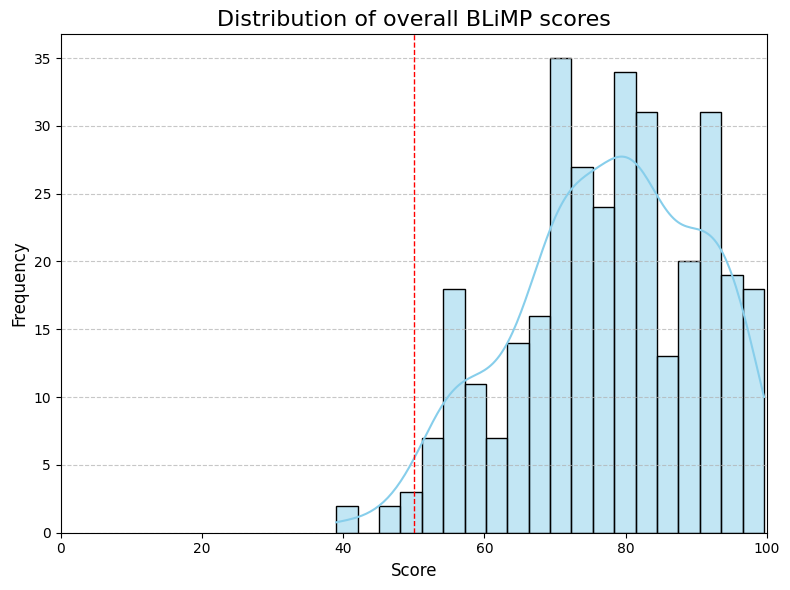

In [4]:
# Filter the dataframe using the 'include_size' column
df_blimp = df[df['include_size'] == True].copy() # 'include_size' contains boolean or 1/0 values

numerical_cols = df_blimp.select_dtypes(include=['number']).columns.tolist()
# Exclude 'id', 'include_size', 'include_training_data' from numerical columns

exclude_cols = {'id', 'include_size', 'include_training_data', 'Avg. Performance'}
phenomena_cols = [col for col in numerical_cols if col not in exclude_cols]

# Melt the dataframe to have 'Linguistic Phenomenon' and 'Score' columns
df_blimp_melted = df_blimp.melt(
    value_vars=phenomena_cols,
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

plt.figure(figsize=(8, 6)) # Adjusted figure size
# Histogram for all scores
sns.histplot(x='Score', data=df_blimp_melted, bins=20, kde=True, color='skyblue')

plt.title('Distribution of overall BLiMP scores', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 100) # Set x-axis limits from 0 to 100
plt.axvline(50, color='red', linestyle='--', linewidth=1) # Add dashed vertical line at 50
plt.tight_layout()
plt.show()

In [5]:
min_score = df_blimp_melted['Score'].min()
max_score = df_blimp_melted['Score'].max()
range_score = max_score - min_score
mean_score = df_blimp_melted['Score'].mean()
median_score = df_blimp_melted['Score'].median()
sd_score = df_blimp_melted['Score'].std()

print(f"Minimum Score: {min_score:.2f}")
print(f"Maximum Score: {max_score:.2f}")
print(f"Range of Scores: {range_score:.2f}")
print(f"Mean Score: {mean_score:.2f}")
print(f"Median Score: {median_score:.2f}")
print(f"Standard Deviation of Scores: {sd_score:.2f}")

Minimum Score: 39.00
Maximum Score: 99.60
Range of Scores: 60.60
Mean Score: 77.40
Median Score: 78.40
Standard Deviation of Scores: 13.11


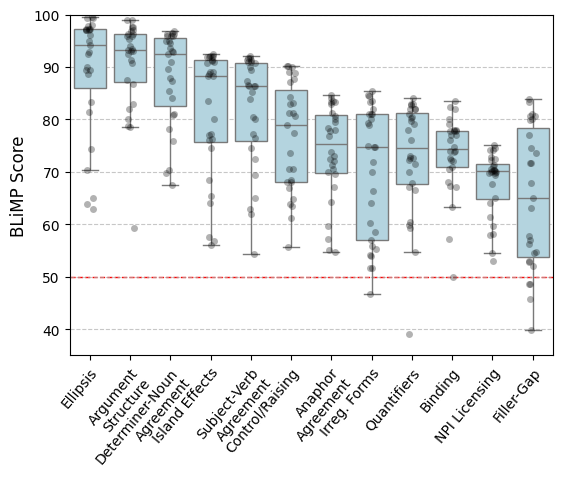

In [6]:
numerical_cols = df_blimp.select_dtypes(include=['number']).columns.tolist()

# Columns to exclude
exclude_cols = {'id', 'include_size', 'include_training_data', 'Avg. Performance'}
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

df_blimp_melted = df_blimp[numerical_cols].melt(var_name='Linguistic Phenomenon', value_name='Score')

# Calculate the median score for each linguistic phenomenon and sort them
average_scores = df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].median().sort_values(ascending=False)
sorted_phenomena = average_scores.index

plt.figure(figsize=(6, 4))
sns.boxplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted, color='lightblue', showfliers=False, order=sorted_phenomena) # showfliers=False to avoid plotting outliers twice
sns.stripplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted, color='black', alpha=0.3, jitter=True, order=sorted_phenomena)


raw_labels = df_blimp_melted['Linguistic Phenomenon'].unique()
wrapped_labels = [textwrap.fill(l, width=16) for l in raw_labels]
#ax.set_xticks(range(len(wrapped_labels)))
#ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', rotation_mode='anchor', fontsize=11)

plt.xlabel('')
plt.ylabel('BLiMP Score', fontsize=12)
plt.ylim(35, 100)
plt.axhline(50, color='red', linestyle='--', linewidth=1, zorder=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.xticks(
    ticks=range(len(wrapped_labels)),
    labels=wrapped_labels,
    rotation=50,
    ha='right',
    rotation_mode='anchor'
)

try:
    plt.savefig("Blimp_scores_individ.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [7]:
mean_per_phenomenon = df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].mean()

mean_per_phenomenon

,Score
Linguistic Phenomenon,
Anaphor Agreement,89.114815
Argument Structure,73.742857
Binding,73.371429
Control/Raising,72.857143
Determiner-Noun Agreement,90.533333
Ellipsis,81.692857
Filler-Gap,76.600000
Irreg. Forms,88.103704
Island Effects,65.000000


In [8]:
df_blimp['Avg. Performance'] = pd.to_numeric(
    df_blimp['Avg. Performance'],
    errors='coerce'
)

human_scores = {
    "Avg. Performance": 88.6,
    "Anaphor Agreement": 97.5,
    "Argument Structure": 90.0,
    "Binding": 87.3,
    "Control/Raising": 83.9,
    "Determiner-Noun Agreement": 92.2,
    "Ellipsis": 85.0,
    "Filler-Gap": 86.9,
    "Irreg. Forms": 97.0,
    "Island Effects": 84.9,
    "NPI Licensing": 88.1,
    "Quantifiers": 86.6,
    "Subject-Verb Agreement": 90.9,
}

In [9]:
df_fix = df_blimp.copy()

if 'dtype' in df_fix.columns:
    df_fix = df_fix.rename(columns={'dtype': 'data_type_label'})

if 'model' not in df_fix.columns:
    df_fix = df_fix.reset_index().rename(columns={'index': 'model'})
df_fix = df_fix.loc[:, ~df_fix.columns.duplicated()].copy()

all_numeric = df_fix.select_dtypes(include=['number']).columns.tolist()
exclude_cols = {'id', 'include_size', 'include_training_data', 'Avg. Performance'}
numerical_cols = [col for col in all_numeric if col in df_fix.columns and col not in exclude_cols]

df_fix['Calculated_Mean'] = df_fix[numerical_cols].mean(axis=1)
df_fix_sorted = df_fix.sort_values('Calculated_Mean')
unique_means = df_fix_sorted['Calculated_Mean'].unique()

worst_val = df_fix['Calculated_Mean'].min() #unique_means[0]
second_worst_val = unique_means[1] if len(unique_means) > 1 else None
best_val = df_fix['Calculated_Mean'].max()

def get_status(val):
    if val == best_val:
        return 'Best TLM'
    #elif val == worst_val:
        #return 'Worst'
    elif second_worst_val is not None and val == second_worst_val:
        return 'Second Worst'
    else:
        return 'Other'

df_fix['Status'] = df_fix['Calculated_Mean'].apply(get_status)

df_blimp_melted = pd.melt(
    df_fix,
    id_vars=['model', 'Calculated_Mean', 'Status'],
    value_vars=numerical_cols,
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

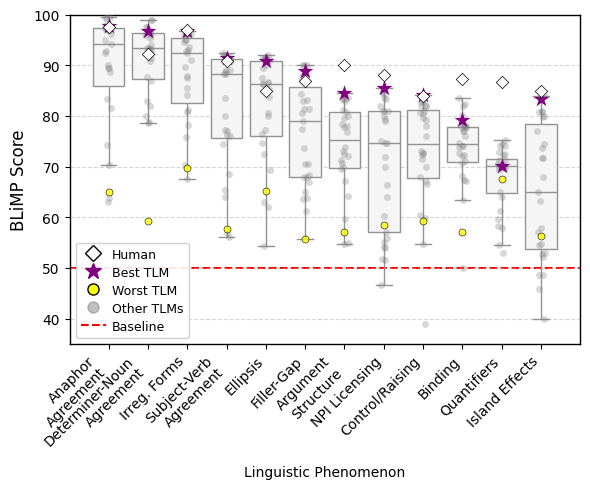

In [10]:
plt.figure(figsize=(6, 5))

# 1. Base Boxplot
sns.boxplot(
    x='Linguistic Phenomenon', y='Score', data=df_blimp_melted,
    color='whitesmoke', showfliers=False, order=sorted_phenomena
)

chance_line = plt.axhline(50, color='red', linestyle='--', linewidth=1.5, zorder=1)
sns.stripplot(
    x='Linguistic Phenomenon', y='Score',
    data=df_blimp_melted[df_blimp_melted['Status'] == 'Other'],
    color='gray', marker='o', alpha=0.3, jitter=True, order=sorted_phenomena
)

sns.stripplot(
    x='Linguistic Phenomenon', y='Score',
    data=df_blimp_melted[df_blimp_melted['Status'] == 'Second Worst'],
    color='yellow', marker='o', alpha=0.8, jitter=True, order=sorted_phenomena,
    edgecolor='black', linewidth=0.5
)

sns.stripplot(
    x='Linguistic Phenomenon', y='Score',
    data=df_blimp_melted[df_blimp_melted['Status'] == 'Best TLM'],
    color='purple', marker='*', size=12, jitter=True, order=sorted_phenomena
)

x_positions = np.arange(len(sorted_phenomena))
human_y = [human_scores.get(p, np.nan) for p in sorted_phenomena]
plt.scatter(x_positions, human_y, color="white", marker="D", s=40, zorder=6, edgecolor='black', linewidth=0.5)

h_human = mlines.Line2D([], [], color='white', marker='D', linestyle='None',
                          markersize=8, markeredgecolor='black', label='Human')
h_best = mlines.Line2D([], [], color='purple', marker='*', linestyle='None',
                         markersize=12, label='Best TLM')
h_worst = mlines.Line2D([], [], color='yellow', marker='o', linestyle='None',
                          markersize=8, markeredgecolor='black', label='Worst TLM')
h_other = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                          markersize=8, alpha=0.5, label='Other TLMs')
h_chance = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1.5, label='Baseline')

# Order: Human -> Best -> Worst -> Other -> Chance
plt.legend(
    handles=[h_human, h_best, h_worst, h_other, h_chance],
    loc='lower left',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    prop={'size': 9},
    labelspacing=0.4,          # Less vertical space between entries
    handletextpad=0.5,         # Less space between symbol and text
    markerscale=1.0
)

plt.ylabel('BLiMP Score', fontsize=12)
plt.ylim(35, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

wrapped_labels = [textwrap.fill(l, width=16) for l in sorted_phenomena]
plt.xticks(ticks=np.arange(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Blimp_scores_updated.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()


**How consistent are models in being good or bad at BLiMP?**
method: ranks of models per linguistic category; Kendall's Tau correlations


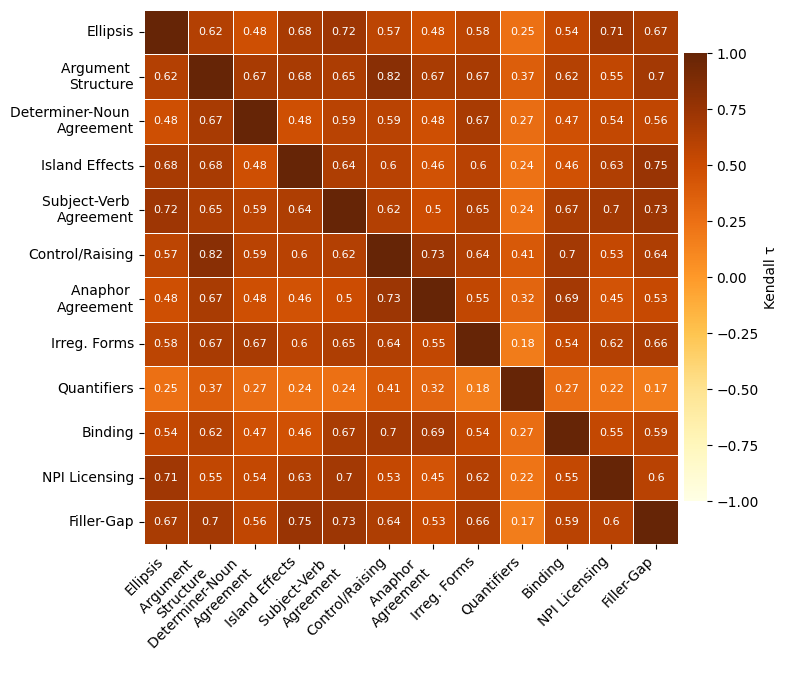

In [11]:
# Kendall's Tau

numerical_cols = df_blimp.select_dtypes(include=['number']).columns.tolist()

exclude_cols = {'id', 'include_size', 'include_training_data', 'Avg. Performance'}
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# rankings of models within each phenomenon (descending order)
ranks = df_blimp[numerical_cols].rank(
    axis=0,
    method="average",
    ascending=False
)

# Kendall tau correlations between phenomena based on jittered rankings
kendall_corr = ranks.corr(method="kendall")

plt.figure(figsize=(8, 7))
threshold = 1.0

# Create annotation matrix: values below threshold, else empty
annot = kendall_corr.copy()
annot = annot.where(annot.abs() < threshold)
annot = annot.round(2).astype(str).replace("nan", "")

labels = kendall_corr.index.tolist()
labels = [label.replace("Agreement", "\nAgreement") for label in labels]
labels = [label.replace("Structure", "\nStructure") for label in labels]


sns.heatmap(
    kendall_corr,
    cmap="YlOrBr",
    vmin=-1,
    vmax=1,
    square=True,
    annot=annot,
    fmt="",
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={"label": "Kendall τ", "shrink": 0.8, "pad": 0.01}  # smaller pad → closer
)

#plt.title("Kendall's tau Correlation of Model Rankings)")
plt.xticks(ticks=np.arange(len(labels)) + 0.5, labels=labels, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(labels)) + 0.5, labels=labels, rotation=0)
plt.tight_layout()

try:
    plt.savefig("Kendall_model_ranks.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [12]:
corr_values = kendall_corr.values

np.fill_diagonal(corr_values, np.nan)

off_diag = corr_values[~np.isnan(corr_values)]

mean_corr = off_diag.mean()
std_corr = off_diag.std()

print(f"Mean Kendall's tau (off-diagonal): {mean_corr:.3f}")
print(f"Std deviation: {std_corr:.3f}")


Mean Kendall's tau (off-diagonal): 0.552
Std deviation: 0.152


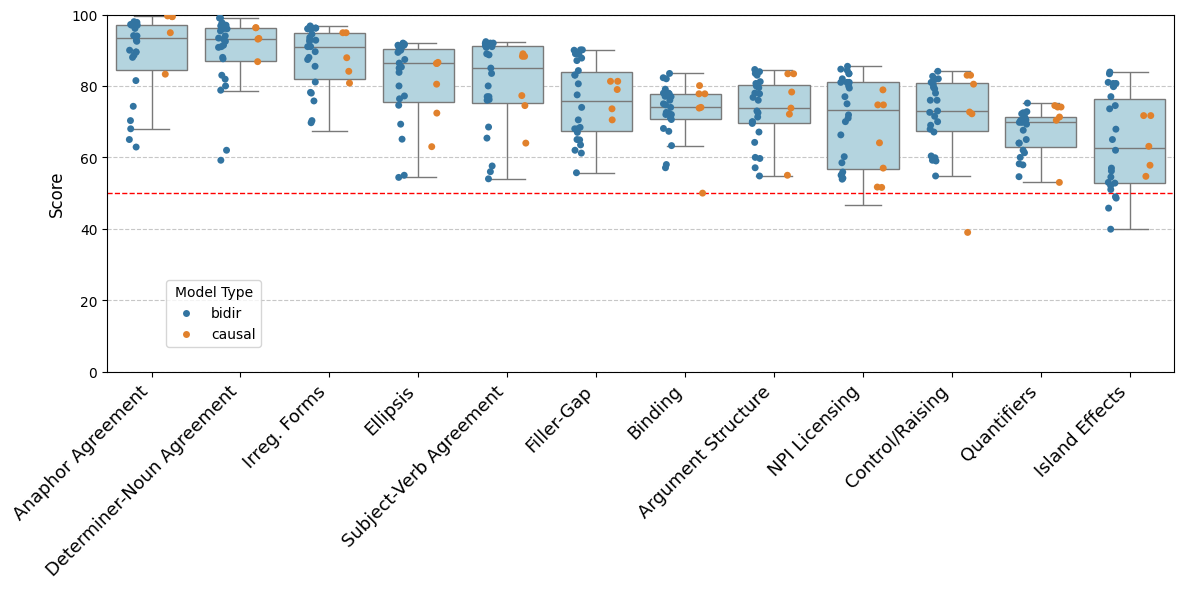

In [13]:
df_blimp = df[df['dataset'] == 'blimp'].copy()

numerical_cols = df_blimp.select_dtypes(include=['number']).columns.tolist()
exclude_cols = {'id', 'include_size', 'include_training_data', 'Avg. Performance'}
phenomena_cols = [col for col in numerical_cols if col not in exclude_cols]

# Melt the dataframe, keeping 'causal/bidir' as an identifier column
df_blimp_melted = df_blimp.melt(
    id_vars=['causal/bidir'],
    value_vars=phenomena_cols,
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

average_scores = df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].median().sort_values(ascending=False)
sorted_phenomena = average_scores.index
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Linguistic Phenomenon',
    y='Score',
    data=df_blimp_melted,
    color='lightblue',
    showfliers=False,
    order=sorted_phenomena
)

sns.stripplot(
    x='Linguistic Phenomenon',
    y='Score',
    hue='causal/bidir',
    data=df_blimp_melted,
    #alpha=0.8,
    jitter=True,
    dodge= True,
    order=sorted_phenomena,
    palette=palette
)

plt.legend(title='Model Type', bbox_to_anchor=(0.1, 0.05), loc='lower center')

#plt.title('Scores for individual linguistic phenomena in BLiMP', fontsize=16)
plt.xlabel('')
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100)
plt.axhline(50, color='red', linestyle='--', linewidth=1)
plt.tight_layout()

try:
    plt.savefig("Blimp_scores_individ.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [14]:
#df_blimp_melted.groupby('Linguistic Phenomenon')["Score"].size()
df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].count()

,Score
Linguistic Phenomenon,
Anaphor Agreement,30
Argument Structure,31
Binding,31
Control/Raising,31
Determiner-Noun Agreement,30
Ellipsis,31
Filler-Gap,30
Irreg. Forms,30
Island Effects,30


In [15]:
df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].mean()

,Score
Linguistic Phenomenon,
Anaphor Agreement,88.536667
Argument Structure,73.251613
Binding,72.883871
Control/Raising,72.387097
Determiner-Noun Agreement,89.513333
Ellipsis,81.206452
Filler-Gap,75.640000
Irreg. Forms,87.860000
Island Effects,63.900000


In [16]:
df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].apply(lambda x: (x > 50).mean() * 100)
((df_blimp_melted['Score'] > 50).mean() * 100)
df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].apply(lambda x: (x > 50).mean() * 100)

,Score
Linguistic Phenomenon,
Anaphor Agreement,19.736842
Argument Structure,20.394737
Binding,19.736842
Control/Raising,19.736842
Determiner-Noun Agreement,19.736842
Ellipsis,20.394737
Filler-Gap,19.736842
Irreg. Forms,19.736842
Island Effects,16.447368


### 2. **Size** : Plot average BLIMP performance x model_size (3 categories)

given the include filter


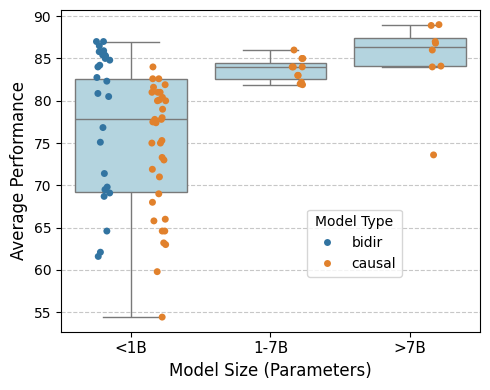

In [17]:
if df['Avg. Performance'].dtype == 'object':
    df['Avg. Performance'] = df['Avg. Performance'].str.replace('%', '', regex=False)

df['Avg. Performance'] = pd.to_numeric(df['Avg. Performance'], errors='coerce')

# Filter the dataframe using the 'include_size' column
df_size = df[df['include_size'] == True].copy() # 'include_size' contains boolean or 1/0 values

custom_order = ['<1B'] + [cat for cat in df_size['size'].unique() if cat != '<1B']
df_size['size'] = pd.Categorical(df_size['size'], categories=custom_order, ordered=True)

#  sort them automatically: size_order = sorted(df_size['size'].unique())

plt.figure(figsize=(5, 4))

# Boxplot for average performance across sizes
sns.boxplot(
    x='size',
    y='Avg. Performance',
    data=df_size,
    color='lightblue',
    showfliers=False,
    order=custom_order,
)

#  Stripplot color-coded by 'causal/bidir'
sns.stripplot(
    x='size',
    y='Avg. Performance',
    hue='causal/bidir',
    data=df_size,
    #alpha=0.8,
    jitter=True,
    order=custom_order,
    palette=palette,
    dodge=True # This separates the dots for causal and bidir slightly for better visibility
)

#plt.title('Average Performance by Model Size and Type', fontsize=16)
plt.xlabel('Model Size (Parameters)', fontsize=12)
plt.ylabel('Average Performance', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Model Type', bbox_to_anchor=(0.83, 0.15), loc='lower right')

plt.tight_layout()
try:
    plt.savefig("Blimp_scores_size.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [18]:
mean_values = df_size.groupby('size')['Avg. Performance'].mean()
print(mean_values)

size
<1B     75.817885
1-7B    83.645455
>7B     84.925000
Name: Avg. Performance, dtype: float64


/tmp/ipykernel_3992/2674183284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df_size.groupby('size')['Avg. Performance'].mean()


In [19]:
median_performance = df_size.groupby('size')['Avg. Performance'].median()
print(median_performance)

size
<1B     77.8
1-7B    84.0
>7B     86.4
Name: Avg. Performance, dtype: float64


/tmp/ipykernel_3992/3724002386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_performance = df_size.groupby('size')['Avg. Performance'].median()


### 3. **Training Data** : Plot average BLIMP performance x training data size

given the include filter


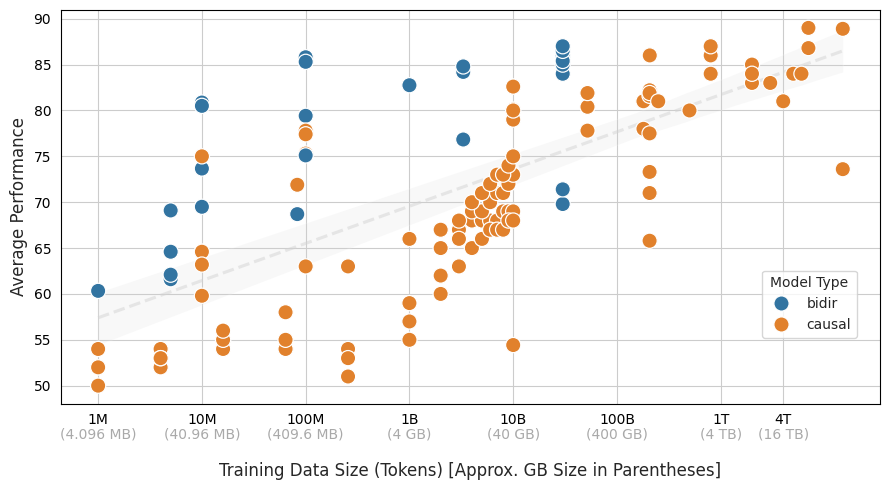

In [20]:
if df['Avg. Performance'].dtype == 'object':
    df['Avg. Performance'] = df['Avg. Performance'].str.replace('%', '', regex=False)
df['Avg. Performance'] = pd.to_numeric(df['Avg. Performance'], errors='coerce')
# Filter the dataframe using the 'include_size' column
df_data = df[df['include_training_data'] == True].copy() # 'include_size' contains boolean or 1/0 values

df_data['Tokens_Billions'] = df_data['training data size'].apply(parse_to_billions)


plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

#  Color coded scatter points
sns.scatterplot(
    data=df_data,
    x='Tokens_Billions',
    y='Avg. Performance',
    hue='causal/bidir',
    palette=palette,
    s=120,
    zorder=5
)

# Global correlation line
sns.regplot(
    data=df_data,
    x='Tokens_Billions',
    y='Avg. Performance',
    logx=True,
    scatter=False,
    color='lightgray', #black
    line_kws={'ls': '--', 'alpha': 0.5, 'label': 'Global Trend'}
)

orientations = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 4000] #[1, 10, 100, 1000] #

plt.xscale('log')
plt.xticks(orientations)
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_tokens))

# Orientation Labels with 1B tokens = 4GB
for val in orientations:
    # 1B tokens / 0.25 = 4 GB
    gb_equiv = val / 0.25
    if gb_equiv >= 1000:
        label = f"({gb_equiv/1000:g} TB)"
    elif gb_equiv >= 1:
        label = f"({gb_equiv:g} GB)"
    else:
        label = f"({gb_equiv*1024:g} MB)"

    plt.text(
        val,
        plt.ylim()[0] - (plt.ylim()[1] - plt.ylim()[0]) * 0.06,
        label,
        ha='center', va='top', fontsize=10, color='darkgray'
    )

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    #spine.set_linewidth(1.5)  # Adjust thickness as needed
ax.tick_params(colors='black', which='both')

plt.legend(title='Model Type', bbox_to_anchor=(0.98, 0.15), loc='lower right')
plt.xlabel('Training Data Size (Tokens) [Approx. GB Size in Parentheses]', fontsize=12, labelpad=25)
plt.ylabel('Average Performance', fontsize=12)
plt.tight_layout()
try:
    plt.savefig("Blimp_scores_training_data.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [21]:
grand_average = df_data['Avg. Performance'].mean()
print(f"Grand Average: {grand_average:.3f}")

Grand Average: 71.420


#### Plot Figures in Parallel

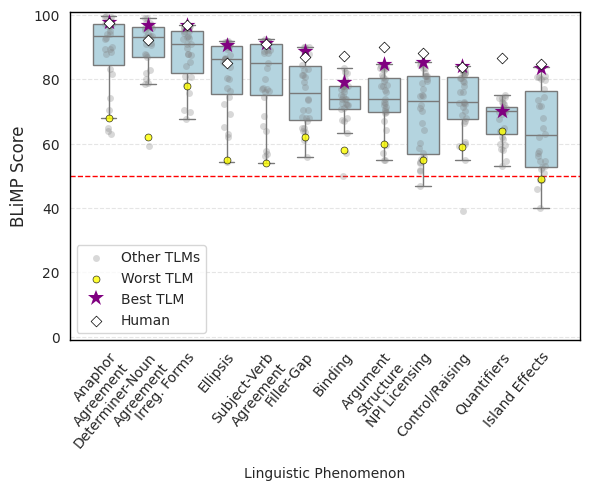

In [22]:
df_fix = df_blimp.copy()

if 'dtype' in df_fix.columns:
    df_fix = df_fix.rename(columns={'dtype': 'data_type_label'})

if 'model' not in df_fix.columns:
    df_fix = df_fix.reset_index().rename(columns={'index': 'model'})
df_fix = df_fix.loc[:, ~df_fix.columns.duplicated()].copy()

all_numeric = df_fix.select_dtypes(include=['number']).columns.tolist()
exclude_cols = {'id', 'include_size', 'include_training_data', 'Avg. Performance'}
numerical_cols = [col for col in all_numeric if col in df_fix.columns and col not in exclude_cols]

df_fix['Calculated_Mean'] = df_fix[numerical_cols].mean(axis=1)

df_fix_sorted = df_fix.sort_values('Calculated_Mean')
unique_means = df_fix_sorted['Calculated_Mean'].unique()

worst_val = df_fix['Calculated_Mean'].min() #unique_means[0]
second_worst_val = unique_means[1] if len(unique_means) > 1 else None
best_val = df_fix['Calculated_Mean'].max()

def get_status(val):
    if val == best_val:
        return 'Best TLM'
    #elif val == worst_val:
        #return 'Worst'
    elif second_worst_val is not None and val == second_worst_val:
        return 'Second Worst'
    else:
        return 'Other'

df_fix['Status'] = df_fix['Calculated_Mean'].apply(get_status)

df_blimp_melted = pd.melt(
    df_fix,
    id_vars=['model', 'Calculated_Mean', 'Status'],
    value_vars=numerical_cols,
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

phenom_medians = df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].median().sort_values(ascending=False)
sorted_phenomena = phenom_medians.index.tolist()

plt.figure(figsize=(6, 5))

# Base Boxplot
sns.boxplot(
    x='Linguistic Phenomenon', y='Score', data=df_blimp_melted,
    color='lightblue', showfliers=False, order=sorted_phenomena
)

# Other models - Gray dots
sns.stripplot(
    x='Linguistic Phenomenon', y='Score',
    data=df_blimp_melted[df_blimp_melted['Status'] == 'Other'],
    color='gray', marker='o', alpha=0.3, jitter=True, order=sorted_phenomena, label='Other TLMs'
)

# Second Worst - Yellow dots with black edge
sns.stripplot(
    x='Linguistic Phenomenon', y='Score',
    data=df_blimp_melted[df_blimp_melted['Status'] == 'Second Worst'],
    color='yellow', marker='o', alpha=0.8, jitter=True, order=sorted_phenomena,
    label='Worst TLM', edgecolor='black', linewidth=0.5
)

# Best and Worst - Stars with purple and green colors
sns.stripplot(
    x='Linguistic Phenomenon', y='Score',
    data=df_blimp_melted[df_blimp_melted['Status'].isin(['Best TLM', 'Worst'])],
    hue='Status', palette={'Best TLM': 'purple', 'Worst': 'green'},
    marker='*', size=12, jitter=True, order=sorted_phenomena, #linewidth=0.5
)

# Human Scores - Diamonds
x_positions = np.arange(len(sorted_phenomena))
human_y = [human_scores.get(p, np.nan) for p in sorted_phenomena]
plt.scatter(x_positions, human_y, color="white", marker="D", s=30, zorder=6, label="Human", linewidth=0.5, edgecolor='black')

plt.ylabel('BLiMP Score', fontsize=12)
#plt.ylim(35, 100)
plt.ylim(-1, 101)

plt.axhline(50, color='red', linestyle='--', linewidth=1, zorder=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Deduplicate legend entries to avoid duplicates from hue layers
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(), by_label.keys(),
    loc='lower left', frameon=True, facecolor='white', framealpha=0.8
)

ax = plt.gca()  # get current axes
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

# Wrap and Rotate X-Labels
wrapped_labels = [textwrap.fill(l, width=16) for l in sorted_phenomena]
plt.xticks(ticks=np.arange(len(wrapped_labels)), labels=wrapped_labels, rotation=45, ha='right')

plt.xticks(ticks=np.arange(len(wrapped_labels)), labels=wrapped_labels, rotation=50, ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.savefig("Blimp_scores_individ_colored.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

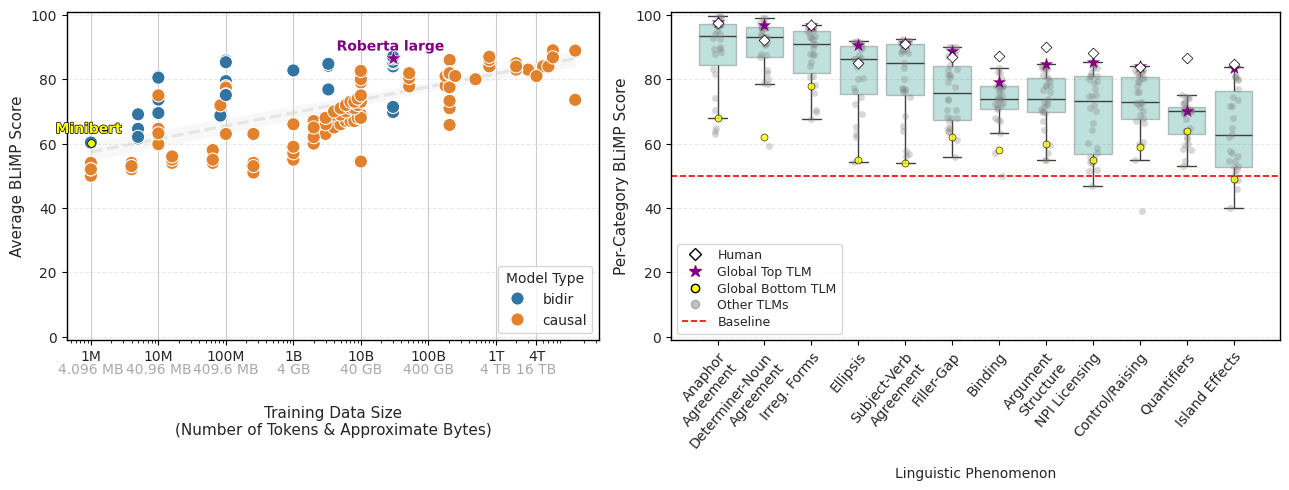

In [23]:
# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [0.7, 0.8]})

# ---------------------------------------------------------
# LEFT PLOT: Training Data vs Performance
# ---------------------------------------------------------
sns.scatterplot(
    data=df_data, x='Tokens_Billions', y='Avg. Performance',
    hue='causal/bidir', palette=palette, s=90, zorder=5, ax=ax1
)

sns.regplot(
    data=df_data, x='Tokens_Billions', y='Avg. Performance',
    logx=True, scatter=False, color='lightgray',
    line_kws={'ls': '--', 'alpha': 0.5, 'label': 'Global Trend'}, ax=ax1
)

ax1.set_xscale('log')
orientations = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 4000]
ax1.set_xticks(orientations)
ax1.xaxis.set_major_formatter(FuncFormatter(format_tokens))

# Add GB/TB Labels
for val in orientations:
    gb_equiv = val / 0.25
    label = f"{gb_equiv/1000:g} TB" if gb_equiv >= 1000 else f"{gb_equiv:g} GB" if gb_equiv >= 1 else f"{gb_equiv*1024:g} MB"
    ax1.text(val, -8, label, ha='center', va='top', fontsize=10, color='darkgray') # ha='center', , va='top',


best_model_name = df_fix[df_fix['Status'] == 'Best TLM']['model'].iloc[0]
worst_model_name = df_fix[df_fix['Status'] == 'Second Worst']['model'].iloc[0]

best_stats = df_data[df_data['model'] == best_model_name]
worst_stats = df_data[df_data['model'] == worst_model_name]

if not best_stats.empty:
    x_val = best_stats['Tokens_Billions'].iloc[0]
    y_val = best_stats['Avg. Performance'].iloc[0]
    m_name = best_stats['model'].iloc[0]

    ax1.scatter(
        x_val, y_val,
        color='purple', marker='*', s=150, zorder=15,
        edgecolor='white', linewidth=0.5, #label='Top BLiMP Performer'
    )

    txt = ax1.text(
        x_val,
        y_val + 1.5,       # Offset slightly above the point (adjust 1.5 as needed)
        m_name,
        color='purple',
        fontsize=10,
        fontweight='bold',
        ha='center',       # Horizontal Alignment: center, left, or right
        va='bottom',       # Vertical Alignment
        zorder=16
    )
    txt.set_path_effects([
        path_effects.withStroke(linewidth=1, foreground='white')
    ])

if not worst_stats.empty:
    x_val = worst_stats['Tokens_Billions'].iloc[0]
    y_val = worst_stats['Avg. Performance'].iloc[0]
    m_name = worst_stats['model'].iloc[0]

    ax1.scatter(
        worst_stats['Tokens_Billions'],
        worst_stats['Avg. Performance'],
        color='yellow', marker='o', s=30, zorder=15,
        edgecolor='black', linewidth=0.5,
        #label='Bottom BLiMP Performer'
    )

    txt = ax1.text(
        x_val, y_val + 2, # Positioned slightly above
        m_name.split("1M tokens")[0],
        color='yellow', # Inside color
        fontsize=10,
        fontweight='bold',
        ha='center', va='bottom',
        zorder=16
    )

    txt.set_path_effects([
        path_effects.withStroke(linewidth=1, foreground='black')
    ])


#ax1.set_ylim(35, 100)
ax1.set_ylim(-1, 101)
ax1.set_ylabel('Average BLiMP Score', fontsize=11)
ax1.set_xlabel('Training Data Size\n(Number of Tokens & Approximate Bytes)', fontsize=11, labelpad=30)
ax1.legend(title='Model Type', loc='lower right', prop={'size': 10})

# ---------------------------------------------------------
# RIGHT PLOT: Linguistic Phenomena Categories (Boxplot)
# ---------------------------------------------------------
# Base Boxplot
sns.boxplot(
    x='Linguistic Phenomenon', y='Score', data=df_blimp_melted,
    boxprops=dict(facecolor="#2A9D8F", alpha=0.3), #color='whitesmoke'
    showfliers=False, order=sorted_phenomena, ax=ax2
)

# Plotting individual model categories
sns.stripplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted[df_blimp_melted['Status'] == 'Other'],
              color='gray', marker='o', alpha=0.3, jitter=True, order=sorted_phenomena, ax=ax2)

sns.stripplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted[df_blimp_melted['Status'] == 'Second Worst'],
              color='yellow', marker='o', alpha=0.8, jitter=True, order=sorted_phenomena, edgecolor='black', linewidth=0.5, ax=ax2)

sns.stripplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted[df_blimp_melted['Status'] == 'Best TLM'],
              color='purple', marker='*', size=10, jitter=True, order=sorted_phenomena, ax=ax2)

# Human Scores
x_pos = np.arange(len(sorted_phenomena))
human_y = [human_scores.get(p, np.nan) for p in sorted_phenomena]
ax2.scatter(x_pos, human_y, color="white", marker="D", s=30, zorder=6, edgecolor='black', linewidth=0.5)

# Chance Line
ax2.axhline(50, color='red', linestyle='--', linewidth=1.2, zorder=1)

h_human = mlines.Line2D([], [], color='white', marker='D', linestyle='None', markersize=6, markeredgecolor='black', label='Human')
h_best = mlines.Line2D([], [], color='purple', marker='*', linestyle='None', markersize=9, label='Global Top TLM')
h_worst = mlines.Line2D([], [], color='yellow', marker='o', linestyle='None', markersize=6, markeredgecolor='black', label='Global Bottom TLM')
h_other = mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=6, alpha=0.5, label='Other TLMs')
h_chance = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1.2, label='Baseline')

ax2.legend(handles=[h_human, h_best, h_worst, h_other, h_chance], loc='lower left', prop={'size': 9}, labelspacing=0.3)

#ax2.set_ylim(35, 100)
ax2.set_ylim(-1, 101)

ax2.set_ylabel('Per-Category BLiMP Score', fontsize=11)
# Ensure labels match the sorted phenomena order 1:1
wrapped_labels = [textwrap.fill(l, width=15) for l in sorted_phenomena]

# Set the positions first
ax2.set_xticks(np.arange(len(wrapped_labels)))

# Apply the labels with rotation and alignment
ax2.set_xticklabels(
    wrapped_labels,
    rotation=50,
    ha='right',
    fontsize=10,
    rotation_mode='anchor'  # This ensures the end of the text aligns with the tick
)

# FORCE TICKS TO BE VISIBLE
ax2.tick_params(axis='x', which='both', bottom=True, labelbottom=True, color='black')
ax2.tick_params(axis='y', which='both', left=True, labelleft=True, color='black')

ax1.tick_params(axis='both', which='both', bottom=True, left=True, color='black')

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Combined_Blimp_Analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()



### 4. **Statistical Model**

In [24]:
# plot for training data scores only

df_data = df_data.rename(
    columns={"Avg. Performance": "Score"}
)

df_data = df_data.rename(
    columns={"causal/bidir": "model_type"}
)

# Higher language category is associated with slightly higher accuracy.

In [25]:
model = smf.ols(
    "Score ~ Tokens_Billions + model_type",
    data=df_data
).fit()
print(model.summary())
# greater amount of training data size is associated with slightly higher accuracy.

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     16.21
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           5.11e-07
Time:                        09:33:14   Log-Likelihood:                -494.13
No. Observations:                 134   AIC:                             994.3
Df Residuals:                     131   BIC:                             1003.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               77.5734 

In [26]:
print(df_data.dtypes)

id                             int64
model                         object
include_size                   int64
include_training_data          int64
training data size            object
dataset                       object
model_type                    object
size                          object
Score                        float64
Ellipsis                     float64
Argument Structure           float64
Determiner-Noun Agreement    float64
Island Effects               float64
Subject-Verb Agreement       float64
Control/Raising              float64
Anaphor Agreement            float64
Irreg. Forms                 float64
Quantifiers                  float64
Binding                      float64
NPI Licensing                float64
Filler-Gap                   float64
Tokens_Billions              float64
dtype: object


In [27]:
df_data["Tokens_Billions"]

,Tokens_Billions
0,30.00
4,800.00
5,800.00
6,800.00
7,207.00
...,...
156,7000.00
163,2000.00
164,30.00
165,0.01


In [28]:
df_data.head(
)

,id,model,include_size,include_training_data,training data size,dataset,model_type,size,Score,Ellipsis,...,Island Effects,Subject-Verb Agreement,Control/Raising,Anaphor Agreement,Irreg. Forms,Quantifiers,Binding,NPI Licensing,Filler-Gap,Tokens_Billions
0,52,Roberta,1,1,30B ~160GB,blimp,bidir,<1B,87.0,92.0,...,81.0,92.0,82.0,97.0,96.0,70.0,78.0,82.0,90.0,30.0
4,120,text-curie-001,1,1,<800B,blimp,causal,1-7B,84.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
5,120,text-davinci-002,1,1,<800B,blimp,causal,>7B,86.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
6,120,text-davinci-003,1,1,<800B,blimp,causal,>7B,87.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
7,121,Pythia 1B,1,1,207 B ~825GB,blimp,causal,1-7B,82.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0


In [29]:
def clean_model_name(x):
    if pd.isna(x):
        return x

    x = str(x).strip().lower()          # normalize case and remove edges
    x = re.sub(r"\s+", " ", x)          # collapse repeated spaces
    x = x.replace("–", "-").replace("—", "-")  # normalize dashes
    x = re.sub(r"[^\w\s\.-]", "", x)    # remove punctuation except . and -
    return x

df_data["model"] = df_data["model"].apply(clean_model_name)

In [30]:
# Clean model column
df_data["model"] = (
    df_data["model"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Create model-specific dataframe
df_model = (
    df_data[["Score", "Tokens_Billions", "model", "id", "model_type"]]
    .dropna()
    .reset_index(drop=True)
)

model = smf.mixedlm(
    formula="Score ~ Tokens_Billions",
    data=df_model,
    groups="model",                 # random intercept for model
    vc_formula={"id": "0 + C(id)"} # additional random intercept for paper ID
).fit()

print(model.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Score    
No. Observations:  134      Method:              REML     
No. Groups:        127      Scale:               9.9171   
Min. group size:   1        Log-Likelihood:      -508.6268
Max. group size:   2        Converged:           Yes      
Mean group size:   1.1                                    
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       70.519    0.936 75.305 0.000 68.683 72.354
Tokens_Billions  0.001    0.000  2.769 0.006  0.000  0.002
id Var          99.019   57.845                           



In [31]:
model = smf.mixedlm(
    formula="Score ~ Tokens_Billions + model_type",
    data=df_model,
    groups="model",                 # random intercept for model
    vc_formula={"id": "0 + C(id)"},
    #vc_formula={"model": "0 + C(model)"}# additional random intercept for paper ID
).fit(reml=False)

print(model.summary())
print("AIC:", model.aic)
print("BIC:", model.bic)

             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Score    
No. Observations:    134        Method:                ML       
No. Groups:          127        Scale:                 13.2395  
Min. group size:     1          Log-Likelihood:        -493.5749
Max. group size:     2          Converged:             Yes      
Mean group size:     1.1                                        
----------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------
Intercept            77.575    1.828 42.432 0.000  73.992 81.158
model_type[T.causal] -9.106    2.076 -4.387 0.000 -13.174 -5.037
Tokens_Billions       0.002    0.000  3.590 0.000   0.001  0.002
id Var               80.347   40.768                            

AIC: 997.1498792151092
BIC: 1011.6390782148637


In [32]:
# FINAL MODEL
model = smf.mixedlm(
    formula="Score ~ Tokens_Billions + model_type",
    data=df_model,
    groups=df_model["model"],
    #groups=df_model["model"],
    re_formula="1",
    vc_formula={"id": "0 + C(id)"}
    #vc_formula={"id": "0 + C(id)"}
    ).fit(reml=False)

print(model.summary())
print("AIC:", model.aic)
print("BIC:", model.bic)

             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Score    
No. Observations:    134        Method:                ML       
No. Groups:          127        Scale:                 13.7596  
Min. group size:     1          Log-Likelihood:        -491.5089
Max. group size:     2          Converged:             Yes      
Mean group size:     1.1                                        
----------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------
Intercept            77.062    1.914 40.255 0.000  73.310 80.814
model_type[T.causal] -8.863    2.156 -4.111 0.000 -13.089 -4.637
Tokens_Billions       0.002    0.000  3.662 0.000   0.001  0.002
Group Var            64.855   27.909                            
id Var               14.816   12.837                            

AIC: 995.0177952839144
BIC: 1012.40483

In [33]:
df_data.head()

,id,model,include_size,include_training_data,training data size,dataset,model_type,size,Score,Ellipsis,...,Island Effects,Subject-Verb Agreement,Control/Raising,Anaphor Agreement,Irreg. Forms,Quantifiers,Binding,NPI Licensing,Filler-Gap,Tokens_Billions
0,52,roberta,1,1,30B ~160GB,blimp,bidir,<1B,87.0,92.0,...,81.0,92.0,82.0,97.0,96.0,70.0,78.0,82.0,90.0,30.0
4,120,text-curie-001,1,1,<800B,blimp,causal,1-7B,84.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
5,120,text-davinci-002,1,1,<800B,blimp,causal,>7B,86.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
6,120,text-davinci-003,1,1,<800B,blimp,causal,>7B,87.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0
7,121,pythia 1b,1,1,207 B ~825GB,blimp,causal,1-7B,82.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0


# 2. Non-BLIMP

1.   **Overview** : Linguistic Phenomenon
2.   **Language Support Category** : Apply categories from Joshi et., al (2020)
3.   **Statistical Model**

## 1. **Overview**: Linguistic Phenomenon

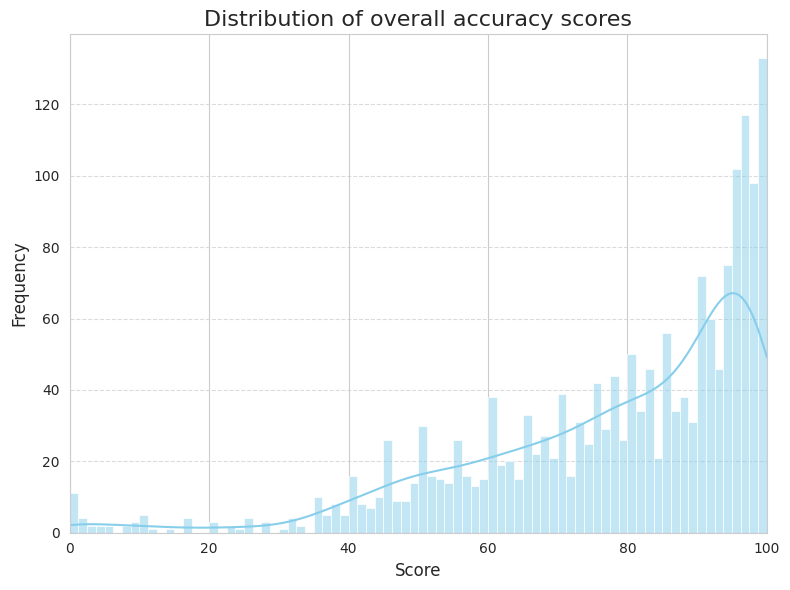

In [34]:
df = pd.read_csv("non_blimp.csv", sep=";")


# Filter the dataframe using the 'exclude' column
df_acc = df[df['exclude'].isna()].copy()

# 'exclude' contains boolean or 1/0 values
# df_acc = df[~df['exclude']].copy()

#extend syntactic phenomena
df_acc['Syntactic_phenomena'] = df_acc['Syntactic_phenomena'].replace("", pd.NA)
df_acc['Syntactic_phenomena'] = df_acc.groupby('id')['Syntactic_phenomena'].ffill()

numerical_cols = df_acc.select_dtypes(include=['number']).columns.tolist()
# Exclude 'id', 'exclude' from numerical columns
exclude_cols = {'id', 'exclude', 'Avg. Performance'} #'Avg. Performance'
#phenomena_cols = [col for col in numerical_cols if col not in exclude_cols]

# filter out benchmarks
phenomena_cols = [
    col for col in numerical_cols
    if col not in exclude_cols and "benchmark" not in col.lower()
]

df_acc[phenomena_cols] = df_acc[phenomena_cols].apply(pd.to_numeric, errors='coerce')

# Melt the dataframe to have 'Linguistic Phenomenon' and 'Score' columns
df_blimp_melted = df_acc.melt(
    value_vars=phenomena_cols,
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

df_blimp_melted["Score"] = df_blimp_melted["Score"] * 100 # match with

plt.figure(figsize=(8, 6)) # Adjusted figure size
# Histogram for all scores
sns.histplot(x='Score', data=df_blimp_melted, bins=80, kde=True, color='skyblue')

plt.title('Distribution of overall accuracy scores', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 100) # Set x-axis limits from 0 to 1
plt.tight_layout()
plt.show()

In [35]:
min_score = df_blimp_melted['Score'].min()
max_score = df_blimp_melted['Score'].max()
range_score = max_score - min_score
mean_score = df_blimp_melted['Score'].mean()
median_score = df_blimp_melted['Score'].median()
sd_score = df_blimp_melted['Score'].std()

print(f"Minimum Score: {min_score:.2f}")
print(f"Maximum Score: {max_score:.2f}")
print(f"Range of Scores: {range_score:.2f}")
print(f"Mean Score: {mean_score:.2f}")
print(f"Median Score: {median_score:.2f}")
print(f"Standard Deviation of Scores: {sd_score:.2f}")

Minimum Score: 0.00
Maximum Score: 100.00
Range of Scores: 100.00
Mean Score: 77.86
Median Score: 83.10
Standard Deviation of Scores: 20.71


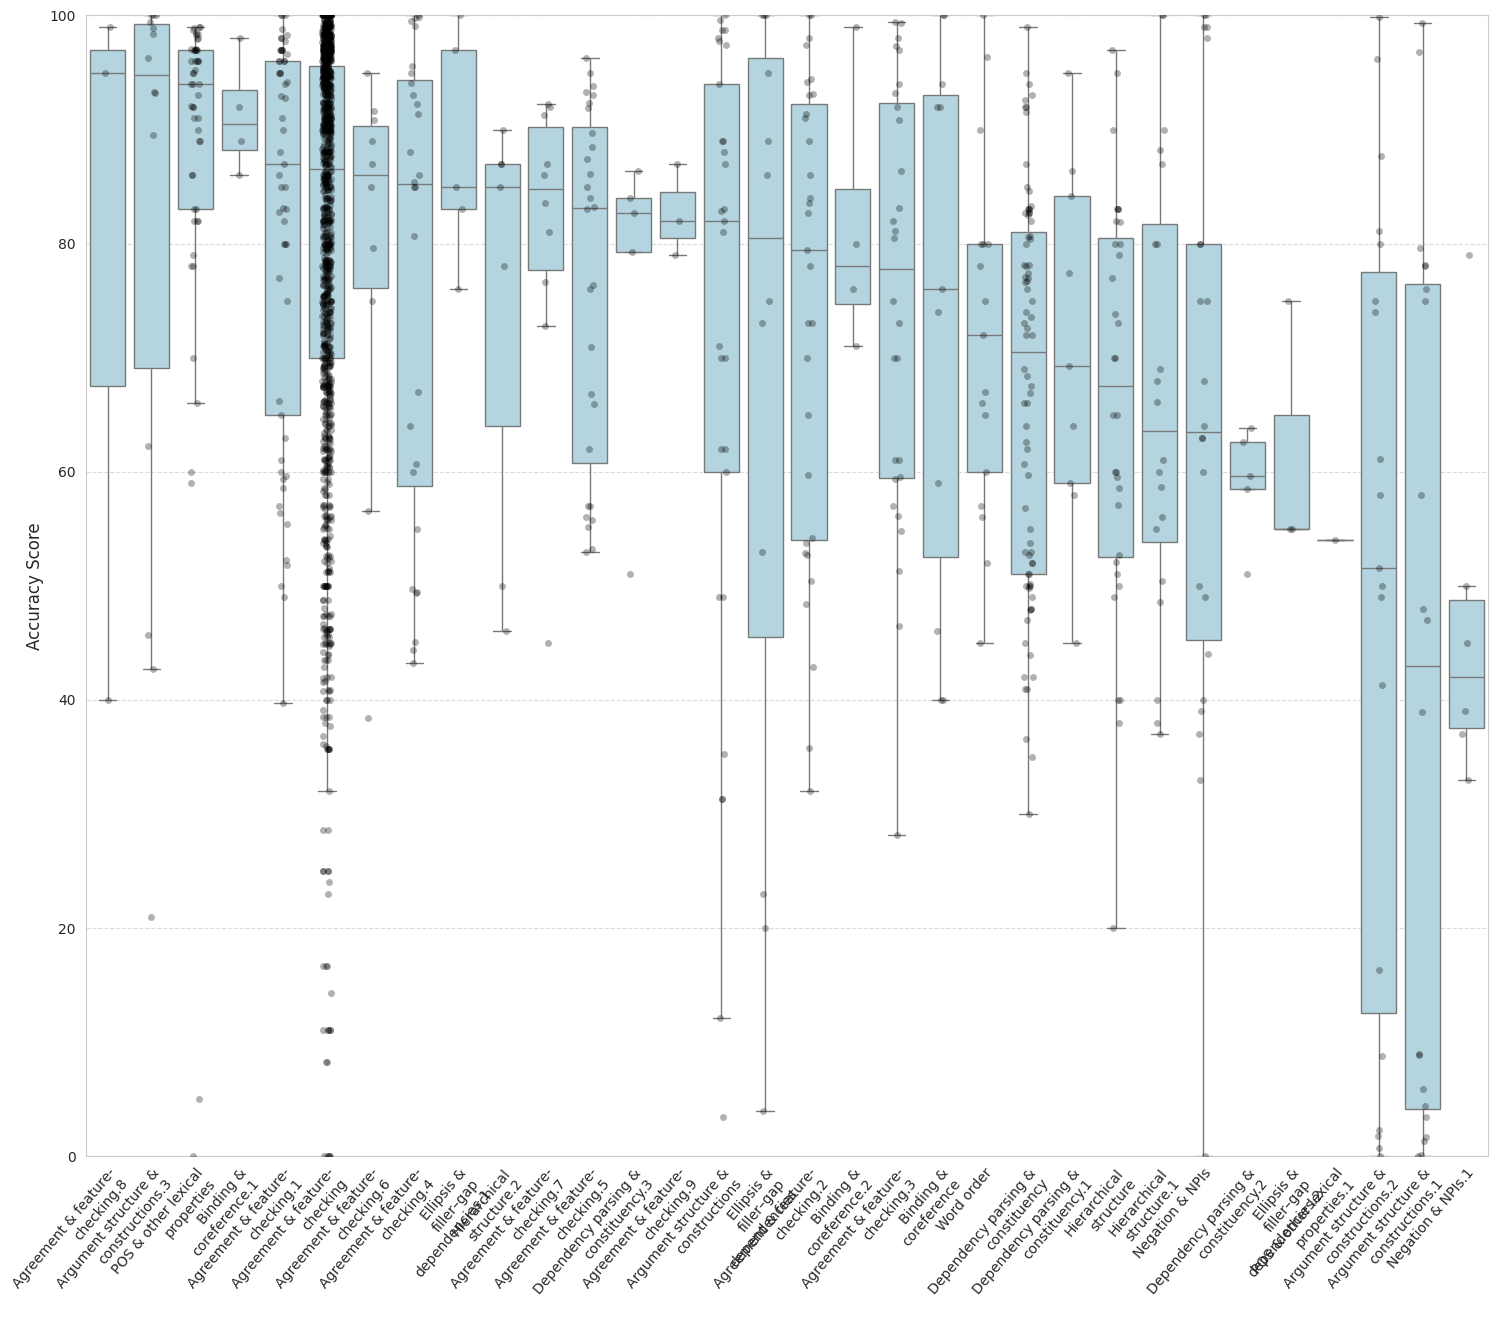

In [36]:
numerical_cols = df_acc.select_dtypes(include=['number']).columns.tolist()

# Columns to exclude # exclude BENCHMARKS
exclude_cols = {'id', 'exclude', 'Avg. Performance', 'causal, bidir'}
numerical_cols = [col for col in df_acc.columns if (col not in exclude_cols and "benchmark" not in col.lower()) and df_acc[col].dtype in ['float64', 'int64']]


#df_blimp_melted = df_acc[numerical_cols].melt(var_name='Linguistic Phenomenon', value_name='Score', id_vars=['id', 'causal, bidir'])
df_blimp_melted = df_acc.melt(
    id_vars=['id', 'causal, bidir'],      # These stay as columns in every row
    value_vars=numerical_cols,          # These get turned into the 'Score' column
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

# remove any category names that have 0 occurrences
#df_blimp_melted['Linguistic Phenomenon'] = df_blimp_melted['Linguistic Phenomenon'].astype(str).astype('category').cat.remove_unused_categories()

df_blimp_melted = df_blimp_melted.dropna(subset=['Score'])
df_blimp_melted["Score"] = df_blimp_melted["Score"] * 100 # match with

df_blimp_melted = df_blimp_melted[df_blimp_melted['Linguistic Phenomenon'] != ""]

# Calculate the median score for each linguistic phenomenon and sort them
average_scores = df_blimp_melted.groupby('Linguistic Phenomenon')['Score'].median().sort_values(ascending=False)
sorted_phenomena = average_scores.index

plt.figure(figsize=(16, 12))
sns.boxplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted, color='lightblue', showfliers=False, order=sorted_phenomena) # showfliers=False to avoid plotting outliers twice
sns.stripplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted, color='black', alpha=0.3, jitter=True, order=sorted_phenomena)


raw_labels = df_blimp_melted['Linguistic Phenomenon'].unique()
wrapped_labels = [textwrap.fill(l, width=20) for l in sorted_phenomena] #raw_labels
#ax.set_xticks(range(len(wrapped_labels)))
#ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', rotation_mode='anchor', fontsize=11)

plt.xlabel('')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 100)
#plt.axhline(50, color='red', linestyle='--', linewidth=1, zorder=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

label_map = dict(zip(sorted_phenomena, wrapped_labels))

plt.xticks(
    ticks=range(len(wrapped_labels)),
    labels=[label_map[p] for p in sorted_phenomena], #labels=wrapped_labels,
    rotation=50,
    ha='right',
    rotation_mode='anchor')

try:
    plt.savefig("Acc_scores_all.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

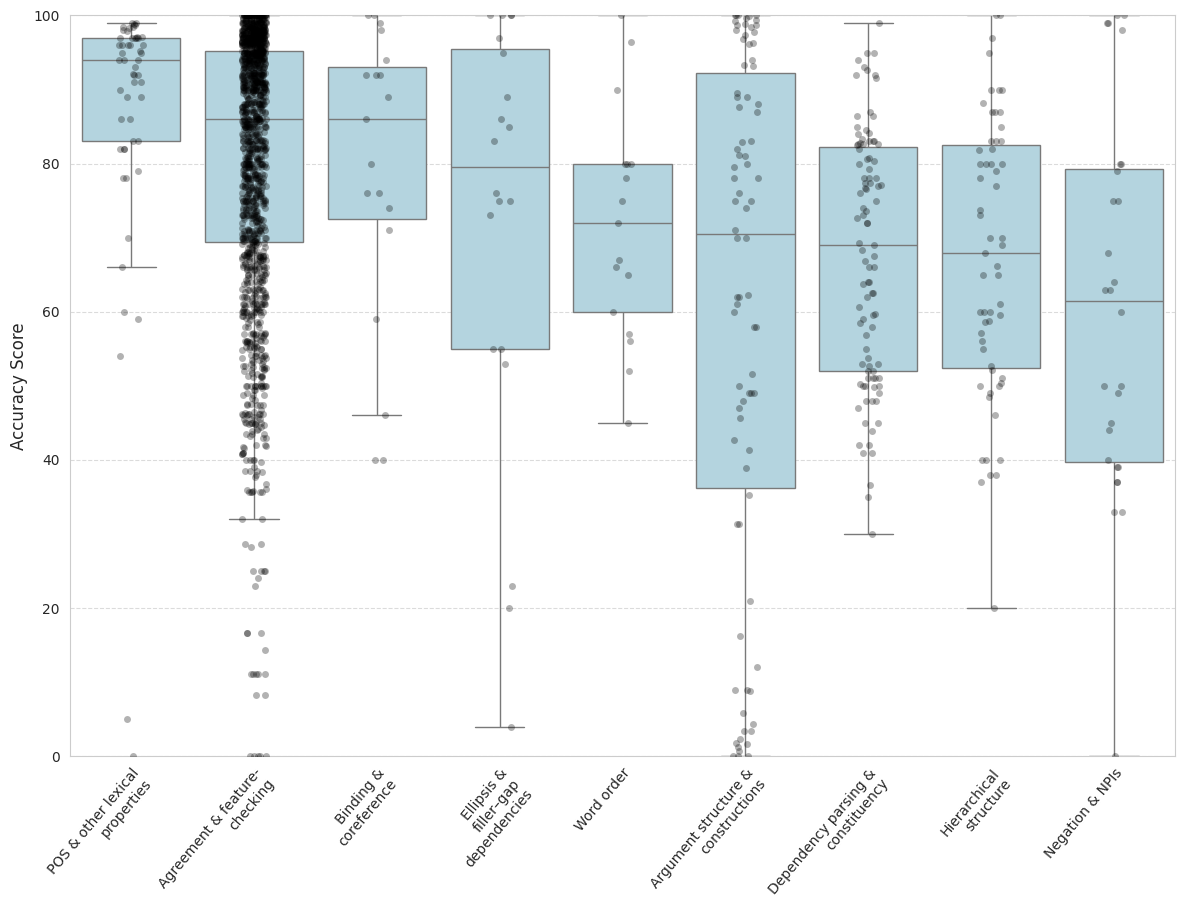

In [37]:
# now average by bins/category

df_blimp_melted['Linguistic Phenomenon'] = (
    df_blimp_melted['Linguistic Phenomenon']
    .str.replace(r"\.\d+$", "", regex=True)
)

average_scores = (
    df_blimp_melted
    .groupby('Linguistic Phenomenon',observed=True)['Score']
    .median()
    .sort_values(ascending=False)
)

sorted_phenomena = average_scores.index

plt.figure(figsize=(12, 8))
sns.boxplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted, color='lightblue', showfliers=False, order=sorted_phenomena) # showfliers=False to avoid plotting outliers twice
sns.stripplot(x='Linguistic Phenomenon', y='Score', data=df_blimp_melted, color='black', alpha=0.3, jitter=True, order=sorted_phenomena)


raw_labels = df_blimp_melted['Linguistic Phenomenon'].unique()
wrapped_labels = [textwrap.fill(l, width=20) for l in sorted_phenomena] #raw_labels
#ax.set_xticks(range(len(wrapped_labels)))
#ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', rotation_mode='anchor', fontsize=11)

plt.xlabel('')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 100)
#plt.axhline(50, color='red', linestyle='--', linewidth=1, zorder=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

label_map = dict(zip(sorted_phenomena, wrapped_labels))

plt.xticks(
    ticks=range(len(wrapped_labels)),
    labels=[label_map[p] for p in sorted_phenomena], #labels=wrapped_labels,
    rotation=50,
    ha='right',
    rotation_mode='anchor')

try:
    plt.savefig("Acc_scores_individ.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

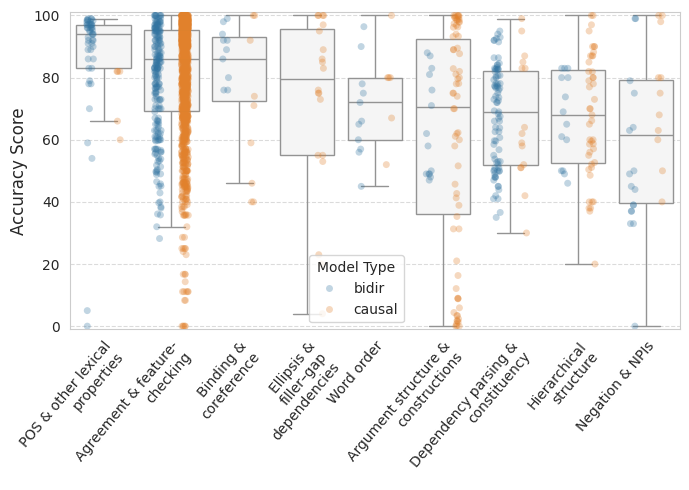

In [38]:
# code multiblimp different & code model type
def categorize(row):
    label = "multiblimp" if row['id'] == 635 else ""
    #return f"{row['causal, bidir']} {label}".strip()
    return f"{row['causal, bidir']}".strip()


df_blimp_melted['Category'] = df_blimp_melted.apply(categorize, axis=1)

df_blimp_melted['Linguistic Phenomenon'] = (
    df_blimp_melted['Linguistic Phenomenon']
    .str.replace(r"\.\d+$", "", regex=True)
)

# Calculate medians for sorting
average_scores = (
    df_blimp_melted
    .groupby('Linguistic Phenomenon')['Score']
    .median()
    .sort_values(ascending=False)
)
sorted_phenomena = average_scores.index

#
plt.figure(figsize=(7, 5))

sns.boxplot(
    x='Linguistic Phenomenon',
    y='Score',
    data=df_blimp_melted,
    #boxprops=dict(facecolor="#2A9D8F", alpha=0.3),
    color='whitesmoke',
    showfliers=False,
    order=sorted_phenomena
)

sns.stripplot(
    x='Linguistic Phenomenon',
    y='Score',
    hue='Category',
    data=df_blimp_melted,
    palette=palette,
    color='gray', alpha=0.3,
    jitter=True,
    order=sorted_phenomena,
    dodge=True
)

wrapped_labels = [textwrap.fill(l, width=20) for l in sorted_phenomena]
label_map = dict(zip(sorted_phenomena, wrapped_labels))

plt.xticks(
    ticks=range(len(wrapped_labels)),
    labels=[label_map[p] for p in sorted_phenomena],
    rotation=50,
    ha='right',
    rotation_mode='anchor'
)

plt.xlabel('')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(-1, 101)
plt.grid(axis='y', linestyle='--', alpha=0.7)

handles, labels = plt.gca().get_legend_handles_labels()
#order = [1, 0, 2] # Example: swap first and second items
#plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order])

#plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(handles, labels , title='Model Type', bbox_to_anchor=(0.47, 0), loc='lower center')

plt.tight_layout()

try:
    plt.savefig("Acc_scores_individ_ling_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.tight_layout()
plt.show()

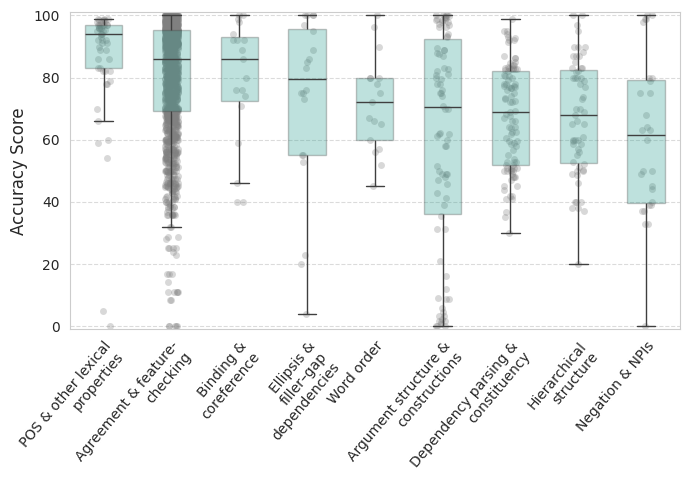

In [39]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x='Linguistic Phenomenon',
    y='Score',
    data=df_blimp_melted,
    boxprops=dict(facecolor="#2A9D8F", alpha=0.3),
    #color='lightblue',
    showfliers=False,
    width=0.55,
    order=sorted_phenomena,
    zorder=3
)

sns.stripplot(
    x='Linguistic Phenomenon',
    y='Score',
    #hue='Category',
    data=df_blimp_melted,
    #palette=palette,
    color='gray', alpha=0.3,
    jitter=True,
    order=sorted_phenomena,
    dodge=True, zorder =2
)

wrapped_labels = [textwrap.fill(l, width=20) for l in sorted_phenomena]
label_map = dict(zip(sorted_phenomena, wrapped_labels))

plt.xticks(
    ticks=range(len(wrapped_labels)),
    labels=[label_map[p] for p in sorted_phenomena],
    rotation=50,
    ha='right',
    rotation_mode='anchor'
)

plt.xlabel('')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(-1, 101)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

handles, labels = plt.gca().get_legend_handles_labels()
plt.tight_layout()

try:
    plt.savefig("Acc_scores_individ_ling_phenomena1.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.tight_layout()
plt.show()

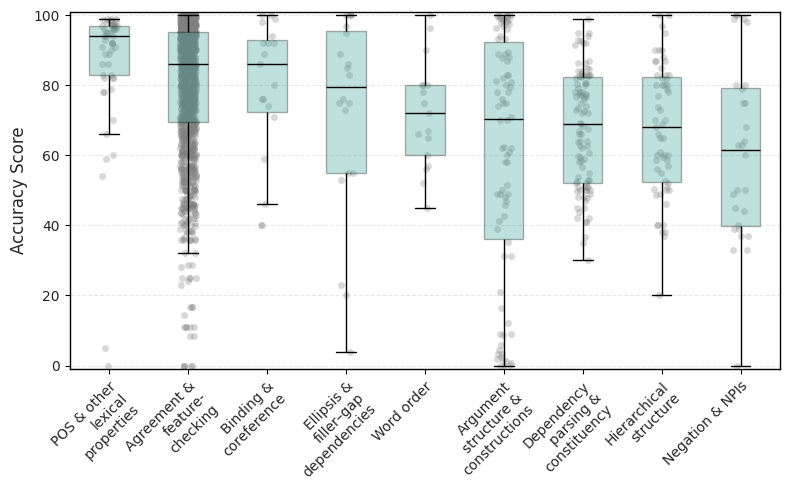

In [40]:
plt.figure(figsize=(8, 5))
ax = plt.gca()

sns.boxplot(
    x='Linguistic Phenomenon',
    y='Score',
    data=df_blimp_melted,
    boxprops=dict(facecolor="#2A9D8F", alpha=0.3, edgecolor="black", linewidth=1),
    medianprops=dict(color='black'), #linewidth=1.2
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    showfliers=False,
    order=sorted_phenomena,
    width=0.5,
    ax=ax,
    zorder=2
)

sns.stripplot(
    x='Linguistic Phenomenon',
    y='Score',
    data=df_blimp_melted,
    color='gray',
    alpha=0.3,
    jitter=True,
    order=sorted_phenomena,
    dodge=True,
    ax=ax,
    zorder=1

)

# --- THE BLACK FRAME LOGIC ---
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)
    spine.set_visible(True)

# Force ticks to be visible on the frame
ax.tick_params(axis='both', which='both', bottom=True, left=True, color='black')

# --- X-AXIS LABELS ---
wrapped_labels = [textwrap.fill(l, width=15) for l in sorted_phenomena]
ax.set_xticks(range(len(wrapped_labels)))
ax.set_xticklabels(
    wrapped_labels,
    rotation=45,
    ha='right',
    rotation_mode='anchor',
    fontsize=10
)

# Styling details
ax.set_xlabel('')
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_ylim(-1, 101)
ax.set_axisbelow(True) # Keeps grid behind the boxes
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

try:
    plt.savefig("Acc_scores_individ_ling_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [41]:
len(df_blimp_melted["id"].unique())

76

In [42]:
#df_blimp_melted.shape[0] 1789

#df_blimp_melted[""].value_counts() #76

#df_acc['language_tested'] = df_acc['language_tested'].str.strip().str.lower()
#df_acc["language_tested"].nunique() #113

## 2.   **Language Support Category** : Apply categories from Joshi et., al (2021)


In [43]:
url = "https://microsoft.github.io/linguisticdiversity/assets/lang2tax.txt"

response = requests.get(url)
lines = response.text.strip().split('\n')

data = dict(line.split(',') for line in lines)

# convert values to int
data = {k: int(v) for k, v in data.items()}

data["chinese"]=5 # add chinese mandarin as chinese
data["standard arabic"]=5 #add as arabic
data["modern greek"]=3 #greek
data["norwegian"]=1  #nynorsk/bokmål
data["northern kurdish"]=1 #kurdish (kurmanji)
data["uighur"]=1  #Uyghur
data["northern sami"]=1 #skolt sami
data["tektiteko"]=0 # tectiteco
data["borôro"]=0 # bororo
data["tupinambá"]=0 # tupi

print(data)
# do automatical match

df['language_tested'] = df['language_tested'].str.strip().str.lower()
df['language_support'] = df['language_tested'].apply(lambda x: data.get(x, "nan"))

{'kàsim': 0, 'mapoyo': 0, 'yamdena': 0, 'rikbaktsa': 0, 'belorussian': 0, 'rengao': 0, 'kodava': 0, 'achumawi': 0, 'türk isaret dili': 0, 'shompen': 0, 'nancowry': 0, "urak lawoi'": 0, 'izhor': 0, 'potawatomi': 0, 'loko': 0, 'mirniny': 0, 'muna': 0, 'isekiri': 0, 'ndonga': 1, 'mochica': 0, 'kangiryuarmiut': 0, 'ngarluma': 0, 'berbice dutch creole': 0, 'jingpho': 0, 'banggi': 0, 'matuumbi': 0, 'sikkimese': 0, 'naskapi': 0, 'muinane': 0, 'bété': 0, 'bini': 0, 'pintupi': 0, 'gahuku': 0, 'ngäbere': 0, 'yelmek': 0, 'remo': 0, 'chuukese': 0, 'biafada': 0, "ma'anyan": 0, 'lusi': 0, 'buriat': 0, 'muruwari': 0, 'sarcee': 0, 'inga': 0, 'yir yiront': 0, 'miisiirii': 0, 'bokar': 0, 'kachari': 0, 'ndut': 0, 'watam': 0, 'nanai': 0, 'pame': 0, 'isirawa': 0, 'kharia': 0, 'lardil': 0, 'gadaba': 0, 'zapotec': 0, 'majang': 0, 'warrongo': 0, 'musom': 0, 'língua de sinais brasileira': 0, 'lisu': 0, 'chipewyan': 0, 'sora': 0, 'laragia': 0, 'kombio': 0, 'yay': 0, 'lamé': 0, 'micmac': 0, 'evenki': 0, 'wantoat

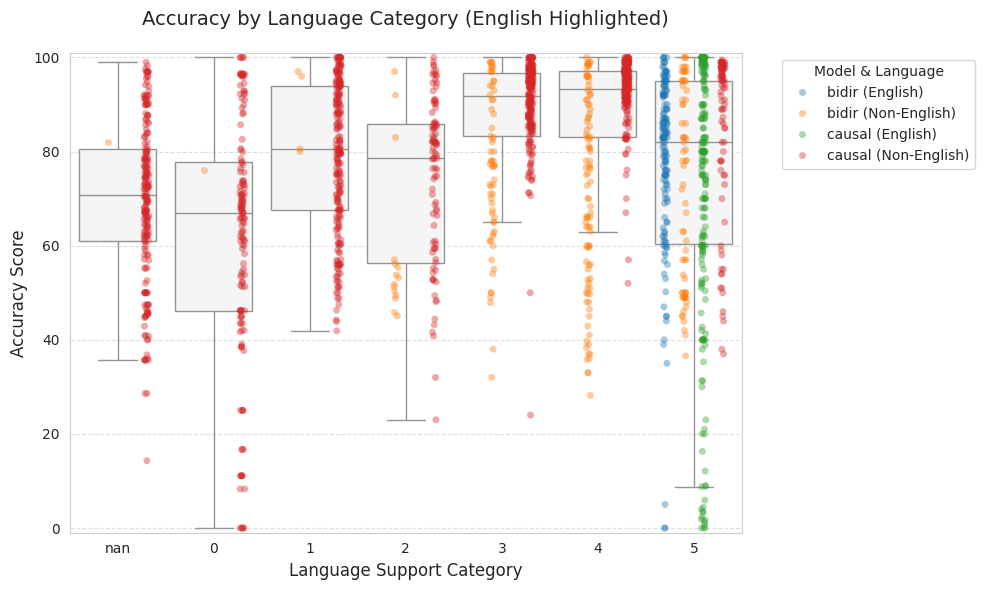

In [44]:
#data["english"]
#df['language_category'].head()

df_acc = df[df['exclude'].isna()].copy()

numerical_cols = df_acc.select_dtypes(include=['number']).columns.tolist()
#if 'id' in numerical_cols:
    #numerical_cols.remove('id')

# Columns to exclude # exclude BENCHMARKS
exclude_cols = {'id', 'exclude', 'Avg. Performance', 'causal, bidir', 'language_support','language_tested'}
numerical_cols = [col for col in df_acc.columns if (col not in exclude_cols and "benchmark" not in col.lower()) and df_acc[col].dtype in ['float64', 'int64']]


df_blimp_melted = df_acc.melt(
    id_vars=['id', 'causal, bidir', 'language_support', 'language_tested'],      # These stay as columns in every row
    value_vars=numerical_cols,          # These get turned into the 'Score' column
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

df_blimp_melted = df_blimp_melted.dropna(subset=['Score'])
df_blimp_melted["Score"] = df_blimp_melted["Score"] * 100 # match with

df_blimp_melted['language_support'] = df_blimp_melted['language_support'].astype(str)

# Create the "English" distinction logic
df_blimp_melted['Status'] = df_blimp_melted['language_tested'].apply(lambda x: 'English' if x == 'english' else 'Non-English')
df_blimp_melted['Group_Hue'] = df_blimp_melted['causal, bidir'] + " (" + df_blimp_melted['Status'] + ")"

# Sort language_category by median score
category_order = (
    df_blimp_melted.groupby('language_support')['Score']
    .median()
    .sort_values(ascending=False)
    .index
)

category_order = ['nan','0', '1', '2', '3', '4', '5']
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_blimp_melted,
    x='language_support',
    y='Score',
    #hue='causal, bidir',
    #hue='Group_Hue',
    color='whitesmoke',
    order=category_order,
    #palette='pastel',
    showfliers=False
)

sns.stripplot(
    data=df_blimp_melted,
    x='language_support',
    y='Score',
    hue='Group_Hue',
    #hue='causal, bidir',
    order=category_order,
    dodge=True,
    alpha=0.4,
    jitter=True,
)

plt.title('Accuracy by Language Category (English Highlighted)', fontsize=14, pad=20)
plt.xlabel('Language Support Category', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
#plt.ylim(-0.05, 1.05)
plt.ylim(-1, 101)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(title='Model & Language', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




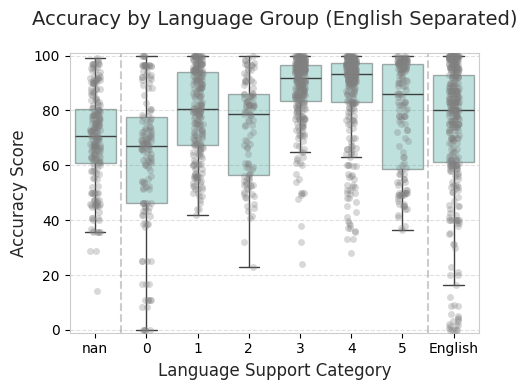

In [45]:
import matplotlib.colors as mcolors
df_blimp_melted.loc[df_blimp_melted['language_tested'].str.lower() == 'english', 'language_support'] = 'English'

# Standardize the rest
df_blimp_melted['language_support'] = df_blimp_melted['language_support'].astype(str)

# Define the order: numerical groups first, English last
category_order = ['nan', '0', '1', '2', '3', '4', '5', 'English']

# Color coding logic
df_blimp_melted['Group_Hue'] = df_blimp_melted['causal, bidir']

# 2. Plotting
plt.figure(figsize=(5, 4))

# Boxplot for the background
sns.boxplot(
    data=df_blimp_melted,
    x='language_support',
    y='Score',
    #hue='Group_Hue',
    boxprops=dict(facecolor="#2A9D8F", alpha=0.3, edgecolor="black", linewidth=1),
    #color= "#2A9D8F",#"lightblue", #'whitesmoke', seashell
    #palette= ['seashell','lightblue'],
    order=category_order,
    showfliers=False
)

# Stripplot for the data points
sns.stripplot(
    data=df_blimp_melted,
    x='language_support',
    y='Score',
    #hue='Group_Hue',
    order=category_order,
    dodge=True,
    alpha=0.3,
    jitter=True,
    #color="#4C72B0","#2A9D8F" #B3B3B3
    color="gray" #palette= palette #'Set1' # Distinct colors for Causal vs Bidir
)


plt.title('Accuracy by Language Group (English Separated)', fontsize=14, pad=20)
plt.xlabel('Language Support Category', fontsize=12) #fontweight='bold'
plt.ylabel('Accuracy Score', fontsize=12)
#plt.ylim(-0.05, 1.05)
plt.ylim(-1, 101)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Clean up duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
'''plt.legend(
    handles[:2], labels[:2],
    title='Model Type',
    bbox_to_anchor=(0.45, 0.2),
    loc='upper left'
)'''

# Add vertical divider line before 'English'
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.2)
plt.axvline(x=6.5, color='black', linestyle='--', alpha=0.2)

plt.tick_params(axis='both', which='both', bottom=True, left=True, color='black', labelcolor='black')

plt.tight_layout()
try:
    plt.savefig("Acc_scores_category_seperated.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

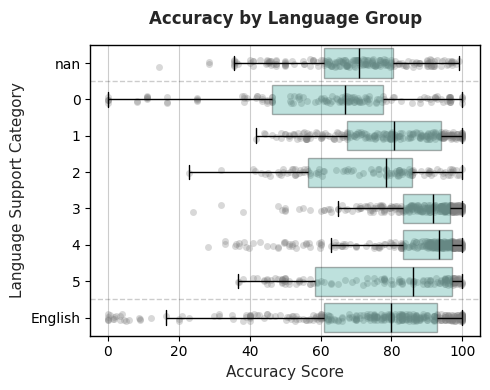

In [46]:
plt.figure(figsize=(5, 4))
ax = plt.gca()

sns.boxplot(
    data=df_blimp_melted,
    x= 'Score',
    y='language_support',
    boxprops=dict(facecolor="#2A9D8F", alpha=0.3, edgecolor="black", linewidth=1),
    medianprops=dict(color='black'), #linewidth=1.5
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    order=category_order,
    showfliers=False,
    ax=ax,
    zorder=2
)

sns.stripplot(
    data=df_blimp_melted,
    x='Score',
    y='language_support',
    order=category_order,
    dodge=True,
    alpha=0.3,
    jitter=True,
    color="gray",
    ax=ax,
    zorder=1
)

# Set frame/spines to black and visible
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)
    spine.set_visible(True)

# Grid Styling
#ax.set_axisbelow(True) # Ensures grid is behind the boxes/points
#ax.grid(axis='y', linestyle='--', alpha=0.4)

# Vertical dividers
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.axhline(y=6.5, color='black', linestyle='--', alpha=0.2, linewidth=1)

# Ticks
ax.tick_params(axis='both', which='both', bottom=True, left=True, color='black', labelcolor='black')

# Titles and Labels
ax.set_title('Accuracy by Language Group', fontsize=12, pad=15, fontweight='bold')
ax.set_xlabel('Accuracy Score', fontsize=11)
ax.set_ylabel('Language Support Category', fontsize=11)
#ax.set_ylim(-1, 101)

plt.tight_layout()

try:
    plt.savefig("Acc_scores_category_seperated.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

/tmp/ipykernel_3992/2674778743.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


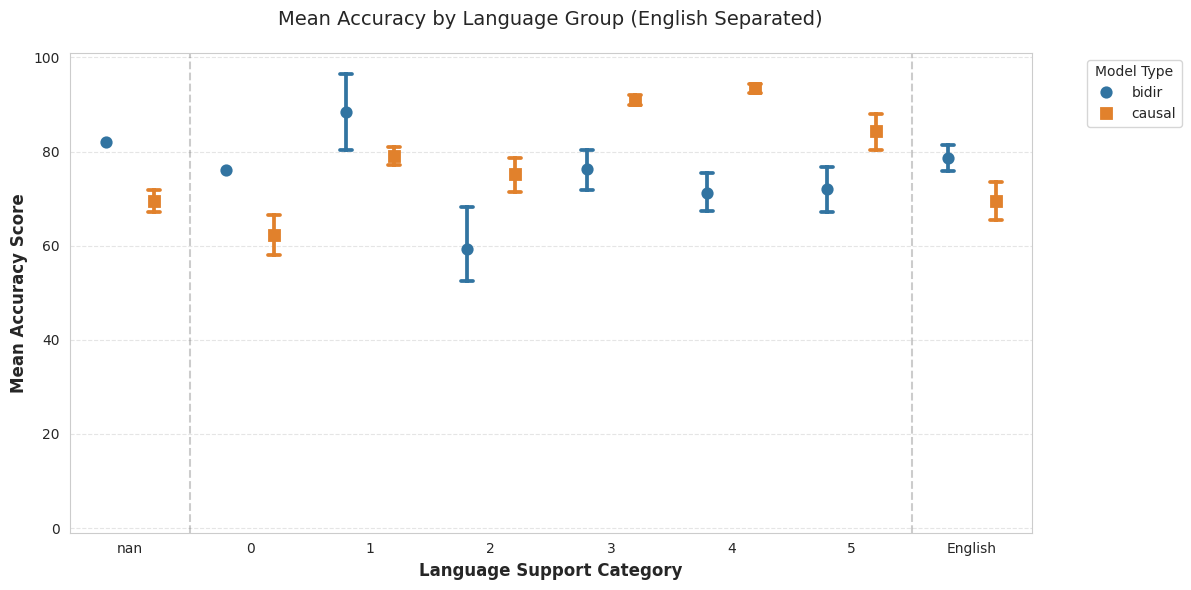

In [47]:
plt.figure(figsize=(12, 6))

sns.pointplot(
    data=df_blimp_melted,
    x='language_support',
    y='Score',
    hue='causal, bidir',      # Model types
    order=category_order,
    dodge=0.4,
    join=False,
    markers=['o', 's'],       # Distinct shapes for causal vs bidir
    palette= palette,
    capsize=.1,               # Adds crossbars to confidence intervals
    errorbar='ci'             # Defaults to 95% confidence interval
)

plt.title('Mean Accuracy by Language Group (English Separated)', fontsize=14, pad=20)
plt.xlabel('Language Support Category', fontsize=12, fontweight='bold')
plt.ylabel('Mean Accuracy Score', fontsize=12, fontweight='bold')
plt.ylim(-1, 101)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add vertical divider line before 'English'
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.2)
plt.axvline(x=6.5, color='black', linestyle='--', alpha=0.2)

plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3992/777989948.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


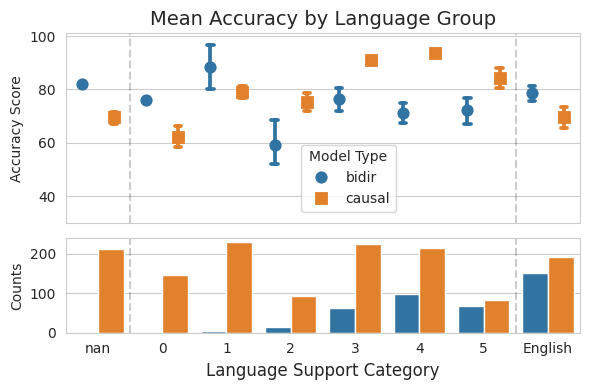

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# --- TOP PLOT: Accuracy (Point Plot) ---
sns.pointplot(
    data=df_blimp_melted,
    x='language_support',
    y='Score',
    hue='causal, bidir',
    order=category_order,
    dodge=0.5,
    join=False,
    markers=['o', 's'],
    palette= palette,
    capsize=.1,
    alpha=1,
    ax=ax1
)
ax1.set_title('Mean Accuracy by Language Group', fontsize=14)
ax1.set_ylabel('Accuracy Score') #fontweight='bold'
ax1.set_ylim(30, 101)
ax1.legend(title='Model Type', bbox_to_anchor=(0.55, 0.45), loc='upper center')

# --- BOTTOM PLOT: Data Counts (Bar Plot) ---
sns.countplot(
    data=df_blimp_melted,
    x='language_support',
    hue='causal, bidir',
    order=category_order,
    palette= palette,
    alpha=1.0,
    saturation=1,
    ax=ax2
)
ax2.set_ylabel('Counts') # fontweight='bold'
ax2.set_xlabel('Language Support Category', fontsize=12) #fontweight='bold'
ax2.get_legend().remove() # Remove duplicate legend

# Add a vertical divider on both plots
for ax in [ax1, ax2]:
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.2)
    ax.axvline(x=6.5, color='black', linestyle='--', alpha=0.2)

plt.tight_layout()

try:
    plt.savefig("Acc_scores_nonblimp_counts.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

## 3. **Statistical Model**

In [49]:
df_acc = df[df['exclude'].isna()].copy()

#extend syntactic phenomena
df_acc['Syntactic_phenomena'] = df_acc['Syntactic_phenomena'].replace("", pd.NA)
df_acc['Syntactic_phenomena'] = df_acc.groupby('id')['Syntactic_phenomena'].ffill()
numerical_cols = df_acc.select_dtypes(include=['number']).columns.tolist()

# Columns to exclude
exclude_cols = {'id', 'exclude', 'Avg. Performance', 'causal, bidir', 'language_support','language_tested'}
numerical_cols = [col for col in df_acc.columns if (col not in exclude_cols and "benchmark" not in col.lower()) and df_acc[col].dtype in ['float64', 'int64']]

df_blimp_melted = df_acc.melt(
    id_vars=['id', 'causal, bidir', 'language_support', 'language_tested', "model"],      # These stay as columns in every row
    value_vars=numerical_cols,          # These get turned into the 'Score' column
    var_name='Linguistic Phenomenon',
    value_name='Score'
)

# now average by bins/category
df_blimp_melted['Linguistic Phenomenon'] = (
    df_blimp_melted['Linguistic Phenomenon']
    .str.replace(r"\.\d+$", "", regex=True)
)

average_scores = (
    df_blimp_melted
    .groupby('Linguistic Phenomenon',observed=True)['Score']
    .median()
    .sort_values(ascending=False)
)

sorted_phenomena = average_scores.index

df_blimp_melted = df_blimp_melted.dropna(subset=['Score'])
df_blimp_melted['language_support'] = df_blimp_melted['language_support'].astype(str)

# Create the "English" distinction logic
df_blimp_melted['Status'] = df_blimp_melted['language_tested'].apply(lambda x: 'English' if x == 'english' else 'Non-English')
df_blimp_melted['Group_Hue'] = df_blimp_melted['causal, bidir'] + " (" + df_blimp_melted['Status'] + ")"

df_blimp_melted["Linguistic Phenomenon"] = df_blimp_melted["Linguistic Phenomenon"].astype("category")
df_blimp_melted["language_support"] = df_blimp_melted["language_support"].astype("float64")


In [50]:
#drop nan
df_blimp_melted = df_blimp_melted.dropna(subset=["language_support"])

# Define predictors
X = df_blimp_melted[["language_support"]]

# Add intercept
X = sm.add_constant(X)

# Target variable
y = df_blimp_melted["Score"]

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())
# Higher language category is associated with slightly higher accuracy.

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     21.28
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           4.29e-06
Time:                        09:33:34   Log-Likelihood:                 240.12
No. Observations:                1577   AIC:                            -476.2
Df Residuals:                    1575   BIC:                            -465.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7448      0.011  

In [51]:
df_blimp_melted["language_support"].unique()

array([5., 4., 3., 0., 1., 2.])

In [52]:
# now with ling. phenomena INCLUDING ENGLISH data points

df_blimp_melted = df_blimp_melted.rename(
    columns={"Linguistic Phenomenon": "Phenomenon"}
)

model = smf.ols(
    "Score ~ language_support + C(Phenomenon)",
    data=df_blimp_melted
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     43.00
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           3.29e-69
Time:                        09:33:34   Log-Likelihood:                 403.55
No. Observations:                1577   AIC:                            -787.1
Df Residuals:                    1567   BIC:                            -733.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [53]:
### df_blimp_melted

df_blimp_melted = df_blimp_melted.rename(
    columns={"Linguistic Phenomenon": "Phenomenon"}
)

# add model type
df_blimp_melted = df_blimp_melted.rename(
    columns={"causal, bidir": "model_type"}
)


model = smf.ols(
    "Score ~ language_support + model_type+ C(Phenomenon, Sum)",
    data=df_blimp_melted
).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     45.99
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.17e-80
Time:                        09:33:34   Log-Likelihood:                 432.57
No. Observations:                1577   AIC:                            -843.1
Df Residuals:                    1566   BIC:                            -784.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [54]:
### add id as random intercept

# Mixed-effects model with random intercept for paper_id
model = smf.mixedlm(
    "Score ~ language_support + model_type + C(Phenomenon, Sum)",
    data=df_blimp_melted,
    groups=df_blimp_melted["id"]
).fit()

print(model.summary())

                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Score   
No. Observations:                1577                   Method:                            REML    
No. Groups:                      76                     Scale:                             0.0277  
Min. group size:                 1                      Log-Likelihood:                    507.1796
Max. group size:                 869                    Converged:                         Yes     
Mean group size:                 20.8                                                              
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

In [55]:
def clean_model_name(x):
    if pd.isna(x):
        return x
    x = str(x).strip().lower()          # normalize case and remove edges
    x = re.sub(r"\s+", " ", x)          # collapse repeated spaces
    x = x.replace("–", "-").replace("—", "-")  # normalize dashes
    x = re.sub(r"[^\w\s\.-]", "", x)    # remove punctuation except . and -
    return x
df_blimp_melted["model"] = df_blimp_melted["model"].apply(clean_model_name)

# Clean the model column first
df_blimp_melted["model"] = (
    df_blimp_melted["model"]
    .astype(str)
    .str.strip()
    .str.lower()
)

model = smf.mixedlm(
    "Score ~ language_support + C(Phenomenon, Sum) + model_type",
    data=df_blimp_melted,
    groups=df_blimp_melted["model"],          # random intercept for paper ID
    vc_formula={"id": "0 + C(id)"}  # additional random intercept for model
).fit()

print(model.summary())

                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Score   
No. Observations:                1577                   Method:                            REML    
No. Groups:                      131                    Scale:                             0.0260  
Min. group size:                 1                      Log-Likelihood:                    506.3573
Max. group size:                 96                     Converged:                         Yes     
Mean group size:                 12.0                                                              
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

In [56]:
model = smf.mixedlm(
    "Score ~ language_support + C(Phenomenon, Sum) + model_type",
    data=df_blimp_melted,
    groups=df_blimp_melted["model"],          # random intercept for paper ID
    vc_formula={"id": "0 + C(id)"}  # additional random intercept for model
).fit(reml=False)

print(model.summary())

print("Log likelihood:", model.llf)
print("AIC:", model.aic)
print("BIC:", model.bic)

                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Score   
No. Observations:                1577                   Method:                            ML      
No. Groups:                      131                    Scale:                             0.0259  
Min. group size:                 1                      Log-Likelihood:                    538.6444
Max. group size:                 96                     Converged:                         Yes     
Mean group size:                 12.0                                                              
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

In [57]:
model = smf.mixedlm(
    "Score ~ language_support + C(Phenomenon, Sum) + model_type",
    data=df_blimp_melted,
    groups=df_blimp_melted["id"],
    #groups=df_blimp_melted["model"],
    re_formula="1",
    vc_formula={"model": "0 + C(model)"}
    #vc_formula={"id": "0 + C(id)"}
).fit(reml=False)

print(model.summary())

print("Log likelihood:", model.llf)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("Random-effect covariance:")
print(model.cov_re)

print("\nVariance components:")
print(model.vcomp)

print("\nResidual variance:")
print(model.scale)

                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Score   
No. Observations:                1577                   Method:                            ML      
No. Groups:                      76                     Scale:                             0.0257  
Min. group size:                 1                      Log-Likelihood:                    559.3048
Max. group size:                 869                    Converged:                         Yes     
Mean group size:                 20.8                                                              
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [58]:
# FINAL MODEL

model = smf.mixedlm(
    "Score ~ language_support + C(Phenomenon, Sum) + model_type",
    data=df_blimp_melted,
    groups=df_blimp_melted["model"],
    #groups=df_blimp_melted["model"],
    re_formula="1",
    vc_formula={"id": "0 + C(id)"}
    #vc_formula={"id": "0 + C(id)"}
).fit(reml=False)

print(model.summary())

print("Log likelihood:", model.llf)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("Random-effect covariance:")
print(model.cov_re)

print("\nVariance components:")
print(model.vcomp)

print("\nResidual variance:")
print(model.scale)

                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                Score   
No. Observations:                1577                   Method:                            ML      
No. Groups:                      131                    Scale:                             0.0259  
Min. group size:                 1                      Log-Likelihood:                    538.7988
Max. group size:                 96                     Converged:                         Yes     
Mean group size:                 12.0                                                              
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/tmp/ipykernel_3992/3406511504.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


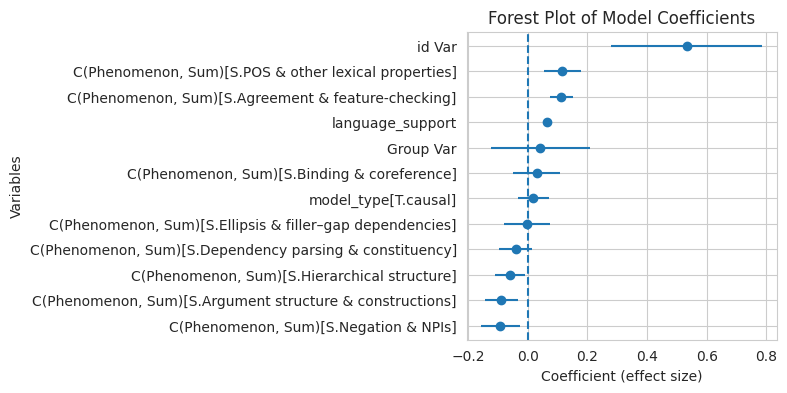

In [59]:
params = model.params
conf = model.conf_int()
conf.columns = ["ci_low", "ci_high"]

df_coef = pd.concat([params, conf], axis=1)
df_coef = df_coef.rename(columns={0: "coef"})

# Remove intercept
df_coef = df_coef.drop("Intercept")

# Optional:remove Phenomenon fixed effects (they can be many)
#df_coef = df_coef[~df_coef.index.str.contains("Phenomenon")]

# Sort by coefficient value
df_coef = df_coef.sort_values("coef")

# Plot
plt.figure(figsize=(4, 4))
plt.errorbar(
    df_coef["coef"],
    df_coef.index,
    xerr=[df_coef["coef"] - df_coef["ci_low"], df_coef["ci_high"] - df_coef["coef"]],
    fmt='o'
)

plt.axvline(0, linestyle='--')  # reference line at 0
plt.xlabel("Coefficient (effect size)")
plt.ylabel("Variables")
plt.title("Forest Plot of Model Coefficients")

plt.tight_layout()
plt.show()

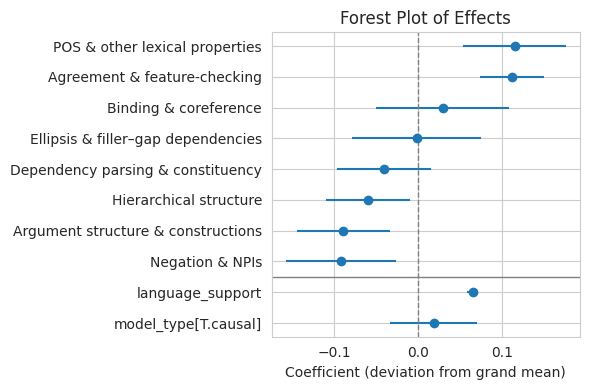

In [60]:
# Extract coefficients + CI
params = model.params
conf = model.conf_int()
conf.columns = ["ci_low", "ci_high"]

df_coef = pd.concat([params, conf], axis=1)
df_coef = df_coef.rename(columns={0: "coef"})

# Drop intercept
df_coef = df_coef.drop("Intercept")

# --- Split into groups ---
df_top = df_coef[
    (
    df_coef.index.str.contains("language_support") |
    df_coef.index.str.contains("model_type")
    # df_coef.index.str.contains("model")|
    # df_coef.index.str.contains("id") exclude random effects
    ) & ~df_coef.index.str.contains("id")
].copy()

df_bottom = df_coef[
    df_coef.index.str.contains("Phenomenon")
].copy()

# --- Sort within each group ---
df_top = df_top.sort_values("coef")
df_bottom = df_bottom.sort_values("coef")

df_plot = pd.concat([df_top, df_bottom])
# Create y positions
y_pos = range(len(df_plot))

plt.figure(figsize=(6, 4))

plt.errorbar(
    df_plot["coef"],
    y_pos,
    xerr=[
        df_plot["coef"] - df_plot["ci_low"],
        df_plot["ci_high"] - df_plot["coef"]
    ],
    fmt='o'
)

df_plot.index = df_plot.index.str.replace(
    r"C\(Phenomenon, Sum\)\[S\.(.*?)\]",
    r"\1",
    regex=True
)

plt.yticks(y_pos, df_plot.index)

# Vertical reference line
plt.axvline(0, linestyle='--', color="gray", linewidth=1)

sep_position = len(df_top) - 0.5
plt.axhline(y=sep_position, linestyle='-', linewidth=1, color="gray")

plt.xlabel("Coefficient (deviation from grand mean)")
plt.title("Forest Plot of Effects")

plt.tight_layout()
plt.savefig("Acc_scores_nonblimp_forestplot.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()

# 3. Probing
1. **Probe Success**: probing often successful (but less if mechanistic),

2. **Location**: middle layers (but just stronger),

3. **Model Type**: a lot of bidir models

4. **Linguistic Phenomena**: something about syntactic phenomena


## 1. **Probe Success**: probing often successful (but less if mechanistic)



In [61]:
df = pd.read_csv("database_final.csv", sep=";")

col="probing"
df_syn = df.copy()

plot_counts(df_syn, col, "probing success", is_exploded=False)

mapping = {
    '0': 'not found',
    '0/m-mixed': 'not found',

    '1': 'found',
    '2': 'found',

    'mixed': 'mixed/critical',
    'm-mixed': 'mixed/critical',
    '0/mixed':'mixed/critical',

}

# already in data... how to plot?
df_syn['grouped'] = df_syn[col].map(mapping)

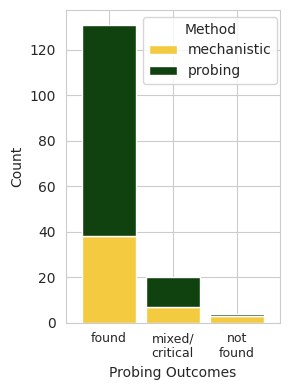

In [62]:
pivot = (
    df_syn
    .groupby(['grouped', 'interp_category'])
    .size()
    .unstack(fill_value=0)
)
pivot

fig, ax = plt.subplots(figsize=(3, 4))  # width, height in inches

pivot_pct = pivot #.div(pivot.sum(axis=1), axis=0) * 100 # model type
#pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

ax = pivot_pct.plot(kind='bar', stacked=True, color= ["#F3CA40", "#104210"], width=0.85, ax=ax)


plt.ylabel('Count')
plt.xlabel('Probing Outcomes')
#plt.xticks(rotation=0)
plt.xticks(rotation=0, ha='center', labels=["found", "mixed/\ncritical", "not\nfound"], ticks=range(len(pivot_pct.index)), fontsize=9)
#plt.title('Distribution of interpretability type within grouped')
plt.legend(title='Method', bbox_to_anchor=(0.33, 1))
plt.tight_layout()
try:
    plt.savefig("probing_found_counts.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [63]:
pivot.div(pivot.sum(axis=0), axis=1) * 100 # model type


interp_category,mechanistic,probing
grouped,,
found,79.166667,86.915888
mixed/critical,14.583333,12.149533
not found,6.250000,0.934579


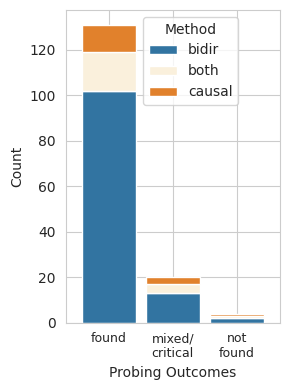

In [64]:
pivot = (
    df_syn
    .groupby(['grouped', 'model_type'])
    .size()
    .unstack(fill_value=0)
)
pivot

fig, ax = plt.subplots(figsize=(3, 4))  # width, height in inches

pivot_pct = pivot #.div(pivot.sum(axis=1), axis=0) * 100 # model type
#pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

ax = pivot_pct.plot(kind='bar', stacked=True, color=palette, width=0.85, ax=ax) # ["#F3CA40", "#104210"]


plt.ylabel('Count')
plt.xlabel('Probing Outcomes')
#plt.xticks(rotation=0)
plt.xticks(rotation=0, ha='center', labels=["found", "mixed/\ncritical", "not\nfound"], ticks=range(len(pivot_pct.index)), fontsize=9)
#plt.title('Distribution of interpretability type within grouped')
plt.legend(title='Method', bbox_to_anchor=(0.33, 1))
plt.tight_layout()
try:
    plt.savefig("probing_found_counts.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)

plt.show()

In [65]:
pivot.div(pivot.sum(axis=0), axis=1) * 100 # model type


model_type,bidir,both,causal
grouped,,,
found,87.179487,77.272727,75.00
mixed/critical,11.111111,18.181818,18.75
not found,1.709402,4.545455,6.25


In [66]:
pivot.sum()

,0
model_type,
bidir,117
both,22
causal,16


## 2. **Location**: middle layers (but just stronger)

In [67]:
df_syn['probing_location'] =  df['probing_location'].apply(
    lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
)
df_exploded = df_syn.explode('probing_location').reset_index(drop=True)

pivot = (
    df_exploded
    .groupby(['probing_location', 'interp_category'])
    .size()
    .unstack(fill_value=0)
)
pivot


interp_category,mechanistic,probing
probing_location,,
lower,3,2
middle,9,26
progressively,4,0
upper,6,6


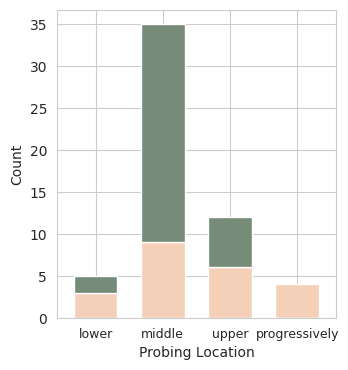

In [68]:
order = ["lower", "middle", "upper", "progressively"]  # your desired order
pivot = pivot.reindex(order)

fig, ax = plt.subplots(figsize=(3.6, 4))  # width, height in inches
pivot.plot(kind='bar', stacked=True, width=0.65,color=["#F5D0B8", "#768B78"], ax=ax) #F3CA40 green, 104210 yellow, F3F0E7
plt.ylabel('Count')
plt.xlabel('Probing Location')

plt.legend().remove()

#plt.legend(title='Method', frameon=True, bbox_to_anchor=(1.6, 1)) #edgecolor='black' loc="upper right",
#plt.title('Mechanistic vs Probing (Stacked) by Location')
plt.xticks(rotation=0, fontsize=9)
#plt.xticks(ha='right', labels=["lower", "middle", "upper   ", "     progressively"], ticks=range(len(pivot.index)))

try:
    plt.savefig("probing_location_counts.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)


plt.show()

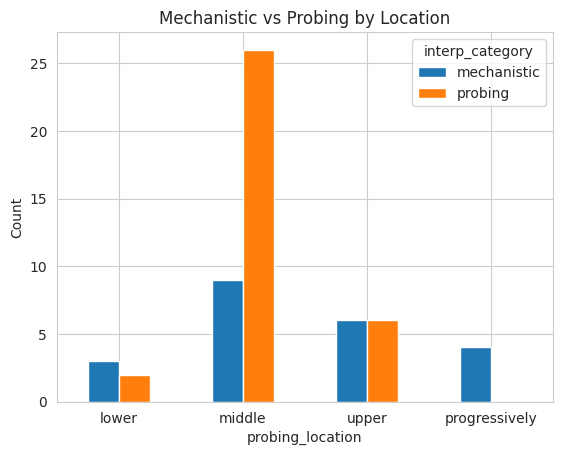

In [69]:
pivot.plot(kind='bar')
plt.ylabel('Count')
plt.title('Mechanistic vs Probing by Location')
plt.xticks(rotation=0)
plt.show()

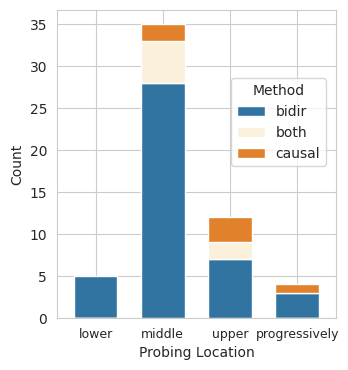

In [70]:
# plot against model type
pivot_model = (
    df_exploded
    .groupby(['probing_location', 'model_type'])
    .size()
    .unstack(fill_value=0)
)

order = ["lower", "middle", "upper", "progressively"]  # your desired order
pivot_model = pivot_model.reindex(order)

fig, ax = plt.subplots(figsize=(3.6, 4))  # width, height in inches
pivot_model.plot(kind='bar', stacked=True, color=palette, width=0.65, alpha=1, ax=ax) #saturation=1

plt.ylabel('Count')
plt.xlabel('Probing Location')

plt.legend(title='Method', bbox_to_anchor=(0.6, 0.8))

#plt.legend(title='Method', frameon=True, bbox_to_anchor=(1.6, 1)) #edgecolor='black' loc="upper right",
#plt.title('Mechanistic vs Probing (Stacked) by Location')
plt.xticks(rotation=0, fontsize=9)
#plt.xticks(ha='right', labels=["lower", "middle", "upper   ", "     progressively"], ticks=range(len(pivot.index)))

try:
    plt.savefig("probing_location_counts_modeltype.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)


In [71]:
# Create the Method pivot (Yellow/Green)
pivot_meth_left = (
    df_syn.groupby(['grouped', 'interp_category'])
    .size()
    .unstack(fill_value=0)
)

# Create the Model Type pivot (Palette)
pivot_mod_left = (
    df_syn.groupby(['grouped', 'model_type'])
    .size()
    .unstack(fill_value=0)
)

standard_order = ["found", "mixed/critical", "not found"]
# (Make sure these match your dataframe strings exactly!)

pivot_meth_left = pivot_meth_left.reindex(standard_order)#.fillna(0)
pivot_mod_left = pivot_mod_left.reindex(standard_order)#.fillna(0)#

colors_method =["#B8B1C3", "#6799A1"] ##E8DAD8
order_right = ["lower", "middle", "upper", "progressively"]
p_method = pivot.reindex(order_right)
p_model = pivot_model.reindex(order_right)

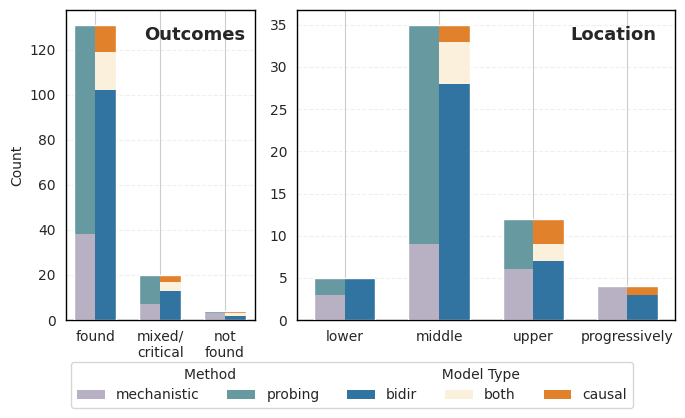

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4), gridspec_kw={'width_ratios': [1, 2]})

# Data Prep for Left Plot
order_left = ["found", "mixed/critical", "not found"]
p_meth_l = df_syn.groupby(['grouped', 'interp_category']).size().unstack(fill_value=0).reindex(order_left).fillna(0)
p_mod_l = df_syn.groupby(['grouped', 'model_type']).size().unstack(fill_value=0).reindex(order_left).fillna(0)
x_left = np.arange(len(order_left))

# Shared Params
total_bar_width = 0.65
half_width = total_bar_width / 2
colors_meth = ["#B8B1C3", "#6799A1"] ##E8DAD8
palette_colors = list(palette.values())

# ==========================================
# LEFT PLOT: Probing Outcomes (Split-Stacked)
# ==========================================
# Method Half
bottom_meth_l = np.zeros(len(order_left))
for i, col in enumerate(p_meth_l.columns):
    ax1.bar(x_left - half_width/2, p_meth_l[col], half_width,
            bottom=bottom_meth_l, color=colors_meth[i], edgecolor='none', align='center')
    bottom_meth_l += p_meth_l[col].values

# Model Type Half
bottom_mod_l = np.zeros(len(order_left))
for i, col in enumerate(p_mod_l.columns):
    ax1.bar(x_left + half_width/2, p_mod_l[col], half_width,
            bottom=bottom_mod_l, color=palette_colors[i], edgecolor='none', align='center')
    bottom_mod_l += p_mod_l[col].values

# Unit Frame logic
for i in range(len(order_left)):
    max_h = max(bottom_meth_l[i], bottom_mod_l[i])
    rect = plt.Rectangle((x_left[i] - half_width, 0), total_bar_width, max_h,
                         fill=False, edgecolor='white', linewidth=1, zorder=3)
    ax1.add_patch(rect)

ax1.set_ylabel('Count', fontsize=10)
ax1.text(0.95, 0.95, "Outcomes", transform=ax1.transAxes,
         fontsize=13, fontweight='bold', ha='right', va='top')
ax1.set_xticks(x_left)
ax1.set_xticklabels(["found", "mixed/\ncritical", "not\nfound"], rotation=0, fontsize=10)

# ==========================================
# RIGHT PLOT: Probing Location (Split-Stacked)
# ==========================================
x_right = np.arange(len(order_right))

# Method Half
bottom_method = np.zeros(len(order_right))
for i, col in enumerate(p_method.columns):
    ax2.bar(x_right - half_width/2, p_method[col], half_width,
            bottom=bottom_method, color=colors_meth[i],
            edgecolor='none', align='center', label=f"{col}")
    bottom_method += p_method[col].values

# Model Type Half
bottom_model = np.zeros(len(order_right))
for i, col in enumerate(p_model.columns):
    ax2.bar(x_right + half_width/2, p_model[col], half_width,
            bottom=bottom_model, color=palette_colors[i],
            edgecolor='none', align='center', label=f"{col}")
    bottom_model += p_model[col].values

for i in range(len(order_right)):
    max_h = max(bottom_method[i], bottom_model[i])
    rect = plt.Rectangle((x_right[i] - half_width, 0), total_bar_width, max_h,
                         fill=False, linewidth=1,edgecolor='white', zorder=3) # edgecolor='black',
    ax2.add_patch(rect)

ax2.text(0.95, 0.95, "Location", transform=ax2.transAxes,
         fontsize=13, fontweight='bold', ha='right', va='top')
ax2.set_xticks(x_right)
ax2.set_xticklabels(order_right, fontsize=10)

# ==========================================
# COMBINED LEGEND ABOVE PLOT
# ==========================================
handles, labels = ax2.get_legend_handles_labels()
fig.legend(
    title ="Method                                               Model Type",
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.51, 0.05),
    ncol=5,
    frameon=True,
    fontsize=10
)

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("probing_combined_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

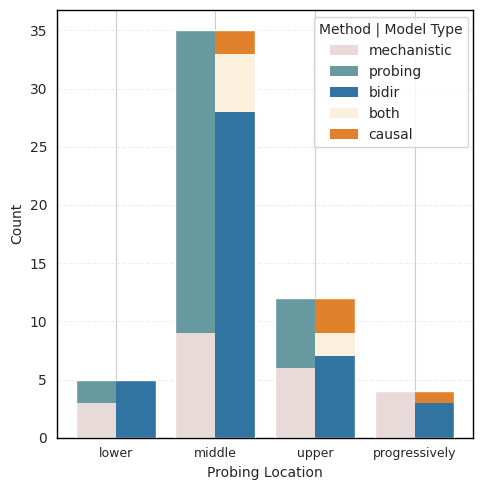

In [73]:
order = ["lower", "middle", "upper", "progressively"]
p_method = pivot.reindex(order)
p_model = pivot_model.reindex(order)

x = np.arange(len(order))
total_bar_width = 0.8  # The combined width of the "split" bar
half_width = total_bar_width / 2  # Width of each side (0.4)

fig, ax = plt.subplots(figsize=(5, 5))

# --- PLOT LEFT HALF: METHOD ---
# We shift the center of the left half to the left by half_width/2
bottom_method = np.zeros(len(order))
colors_method = ["#E8DAD8", "#6799A1"]

for i, col in enumerate(p_method.columns):
    ax.bar(x - half_width/2, p_method[col], half_width,
           bottom=bottom_method, color=colors_method[i], alpha=1,
           label=f"Method: {col}", edgecolor='none', align='center')
    bottom_method += p_method[col].values

# --- PLOT RIGHT HALF: MODEL TYPE ---
# We shift the center of the right half to the right by half_width/2
bottom_model = np.zeros(len(order))
palette_colors = list(palette.values())

for i, col in enumerate(p_model.columns):
    ax.bar(x + half_width/2, p_model[col], half_width,
           bottom=bottom_model, color=palette_colors[i], alpha=1,
           label=f"Model: {col}", edgecolor='none', align='center')
    bottom_model += p_model[col].values

for i in range(len(order)):
    # Calculate the max height to draw the outer frame
    max_h = max(bottom_method[i], bottom_model[i])
    rect = plt.Rectangle((x[i] - half_width, 0), total_bar_width, max_h,
                          fill=False, edgecolor='white', linewidth=1, zorder=4)
    ax.add_patch(rect)

# Remove default spines but keep the frame logic
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.set_ylabel('Count',  fontsize=10)
ax.set_xlabel('Probing Location', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=9)

# Clean Y-axis
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Deduplicating legend to avoid redundant prefixes
handles, labels = ax.get_legend_handles_labels()
# Optional: clean up the labels for the legend
clean_labels = [l.split(': ')[1] for l in labels]

ax.legend(handles, clean_labels, loc='upper left', bbox_to_anchor=(0.6, 1),
          title="Method | Model Type", frameon=True) #edgecolor='black'

plt.tight_layout()
plt.savefig("split_stacked_probing.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
pivot_model
#pivot_model.div(pivot_model.sum(axis=1), axis=0) * 100 # model type



model_type,bidir,both,causal
probing_location,,,
lower,5,0,0
middle,28,5,2
upper,7,2,3
progressively,3,0,1


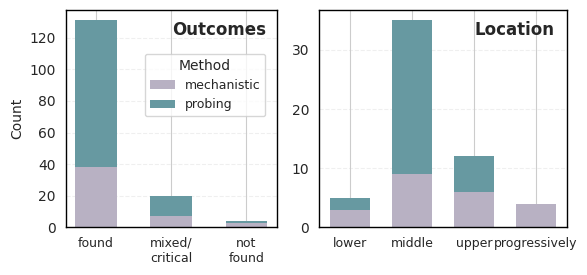

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [0.85, 1]})

order_left = ["found", "mixed/critical", "not found"]
# Ensure p_meth_l and p_method are available from your dataframe
p_meth_l = df_syn.groupby(['grouped', 'interp_category']).size().unstack(fill_value=0).reindex(order_left).fillna(0)

colors_meth = ["#B8B1C3", "#6799A1"]
bar_width = 0.65

x_left = np.arange(len(order_left))
bottom_l = np.zeros(len(order_left))

for i, col in enumerate(p_meth_l.columns):
    ax1.bar(x_left, p_meth_l[col], 0.55, bottom=bottom_l,
            color=colors_meth[i], edgecolor='none')
    bottom_l += p_meth_l[col].values


ax1.set_ylabel('Count', fontsize=10)
ax1.set_xticks(x_left)
ax1.set_xticklabels(["found", "mixed/\ncritical", "not\nfound"], fontsize=9)
ax1.text(0.95, 0.95, "Outcomes", transform=ax1.transAxes, fontsize=12, fontweight='bold', ha='right', va='top')


x_right = np.arange(len(order_right))
bottom_r = np.zeros(len(order_right))

for i, col in enumerate(p_method.columns):
    ax2.bar(x_right, p_method[col], bar_width, bottom=bottom_r,
            color=colors_meth[i], edgecolor='none', label=col)
    bottom_r += p_method[col].values



ax2.set_xticks(x_right)
ax2.set_xticklabels(order_right, fontsize=9)
ax2.text(0.95, 0.95, "Location", transform=ax2.transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc='center',
           bbox_to_anchor=(0.35, 0.7), ncol=1, frameon=True, fontsize=9) #1.07, 0.6)

for ax in [ax1, ax2]:
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("probing_combined_clean.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

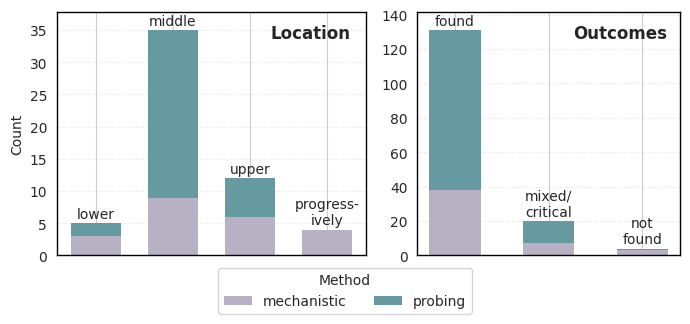

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw={'width_ratios': [1, 0.85]})

order_left = ["found", "mixed/critical", "not found"]
p_meth_l = df_syn.groupby(['grouped', 'interp_category']).size().unstack(fill_value=0).reindex(order_left).fillna(0)

colors_meth = ["#B8B1C3", "#6799A1"]
bar_width = 0.65

x_left = np.arange(len(order_left))
bottom_l = np.zeros(len(order_left))

for i, col in enumerate(p_meth_l.columns):
    ax2.bar(x_left, p_meth_l[col], 0.55, bottom=bottom_l,
            color=colors_meth[i], edgecolor='none')
    bottom_l += p_meth_l[col].values

labels_left = ["found", "mixed/\ncritical", "not\nfound"]
for i, total_h in enumerate(bottom_l):
    if True: #total_h < 20
        y_pos = total_h + (max(bottom_l) * 0.01)
        v_align = 'bottom'
        text_color = 'black'
    else:
        y_pos = total_h / 2
        v_align = 'center'
        text_color = 'black'

    ax2.text(x_left[i], y_pos, labels_left[i], ha='center', va=v_align,
             fontsize=10) #rotation=90,


ax2.set_xticks(x_left)
ax2.set_xticklabels([]) # Hide default text labels
ax2.text(0.95, 0.95, "Outcomes", transform=ax2.transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

x_right = np.arange(len(order_right))
bottom_r = np.zeros(len(order_right))

for i, col in enumerate(p_method.columns):
    ax1.bar(x_right, p_method[col], bar_width, bottom=bottom_r,
            color=colors_meth[i], edgecolor='none', label=col)
    bottom_r += p_method[col].values

for i, total_h in enumerate(bottom_r):
    if True:
        y_pos = total_h + (max(bottom_r) * 0.01)
        v_align = 'bottom'
        text_color = 'black'
    else:
        y_pos = total_h / 2
        v_align = 'center'
        text_color = 'black'

    clean_label = order_right[i].replace("progressively", "progress-\nively")
    ax1.text(x_right[i], y_pos,clean_label, ha='center', va=v_align,
            fontsize=10) #rotation=90,

ax1.set_ylabel('Count', fontsize=10)
ax1.set_xticks(x_right)
ax1.set_xticklabels([]) # Hide default text labels
ax1.text(0.95, 0.95, "Location", transform=ax1.transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc='center',
           bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=True, fontsize=10)

ax2.set_ylim(0, max(bottom_l) * 1.08)
ax1.set_ylim(0, max(bottom_r) * 1.08)

for ax in [ax1, ax2]:
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("probing_combined_clean.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

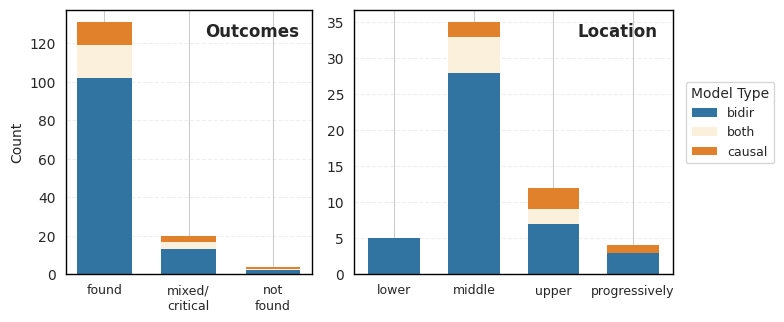

In [77]:

order_left = ["found", "mixed/critical", "not found"]
p_mod_l = df_syn.groupby(['grouped', 'model_type']).size().unstack(fill_value=0).reindex(order_left).fillna(0)

order_right = ["lower", "middle", "upper", "progressively"]
p_mod_r = p_model.reindex(order_right).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.3]})

bar_width = 0.65
colors_mod = list(palette.values())

x_left = np.arange(len(order_left))
bottom_l = np.zeros(len(order_left))

for i, col in enumerate(p_mod_l.columns):
    ax1.bar(x_left, p_mod_l[col], bar_width, bottom=bottom_l,
            color=colors_mod[i], edgecolor='none', label=col) #alpha=0.8
    bottom_l += p_mod_l[col].values

ax1.set_ylabel('Count', fontsize=10)
ax1.set_xticks(x_left)
ax1.set_xticklabels(["found", "mixed/\ncritical", "not\nfound"], fontsize=9)
ax1.text(0.95, 0.95, "Outcomes", transform=ax1.transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

x_right = np.arange(len(order_right))
bottom_r = np.zeros(len(order_right))

for i, col in enumerate(p_mod_r.columns):
    ax2.bar(x_right, p_mod_r[col], bar_width, bottom=bottom_r,
            color=colors_mod[i], edgecolor='none') #alpha=0.8
    bottom_r += p_mod_r[col].values

ax2.set_xticks(x_right)
ax2.set_xticklabels(order_right, fontsize=9)
ax2.text(0.95, 0.95, "Location", transform=ax2.transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

# Grab handles from ax1 since it has the labels
handles, labels = ax1.get_legend_handles_labels()

fig.legend(handles, labels, title="Model Type", loc='lower center',
           bbox_to_anchor=(1.05, 0.5), ncol=1, frameon=True, fontsize=9)

for ax in [ax1, ax2]:
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    # Uniform Black Frame
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("probing_model_type_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## 3. **Model Type**: a lot of bidir models

In [78]:
counts = (
    df_syn
    .groupby(['grouped', 'model_type'])
    .size()
    .reset_index(name='count')
)

pivot = (
    df_syn
    .groupby(['grouped', 'model_type'])
    .size()
    .unstack(fill_value=0)
)
pivot

model_type,bidir,both,causal
grouped,,,
found,102,17,12
mixed/critical,13,4,3
not found,2,1,1


## 4. **Linguistic Phenomena**: something about syntactic phenomena


In [79]:
col= "syntactic_phenomena"
df_syn = df.copy()
df_syn[col] = df_syn[col].apply(clean_syntactic_phenomena)
df_syn_exp = df_syn.explode(col).dropna(subset=[col]).copy()

df_syn_exp['grouped'] = df_syn_exp["probing"].map(mapping)
#df_models_exploded["syntactic_phenomena"] = df["syntactic_phenomena"].apply(clean_syntactic_phenomena)
#df_models_exploded = df_models_exploded.explode("syntactic_phenomena").dropna(subset=["syntactic_phenomena"]).copy()

#pivot_percentage = pivot / pivot.values.sum() * 100
pivot = pd.crosstab(df_syn_exp['syntactic_phenomena'], df_syn_exp['grouped'])
pivot


grouped,found,mixed/critical,not found
syntactic_phenomena,,,
agreement and feature-checking,38,8,0
argument structure and other constructions,26,3,1
benchmark,8,1,1
binding and coreference,14,2,0
dependency parsing and constituency,52,7,2
ellipsis and filler-gap dependencies,6,2,0
hierarchical structure,25,6,0
negation and npis,9,2,0
pos,35,11,0


In [80]:
pivot['not_found_or_mixed'] = pivot['mixed/critical'] + pivot['not found']

# Keep only the two categories
collapsed = pivot[['found', 'not_found_or_mixed']]
collapsed

grouped,found,not_found_or_mixed
syntactic_phenomena,,
agreement and feature-checking,38,8
argument structure and other constructions,26,4
benchmark,8,2
binding and coreference,14,2
dependency parsing and constituency,52,9
ellipsis and filler-gap dependencies,6,2
hierarchical structure,25,6
negation and npis,9,2
pos,35,11


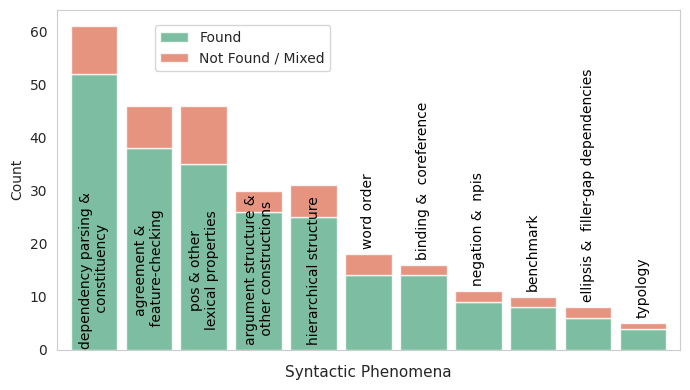

In [81]:
percent= collapsed
percent = percent.sort_values(by=percent.columns[0], ascending=False)
ax = percent.plot(kind='bar', stacked=True, figsize=(7, 4), color=['#5DAE8B', '#E07A5F'], width=0.85, alpha=0.8) # #4CAF50 #F44336

old_labels = percent.index.tolist()
new_labels = [
    label.replace('and', '&\n').lower().replace('pos', 'pos & other\nlexical properties')
    for label in old_labels
]

for i, (label_text, (index, row)) in enumerate(zip(new_labels, percent.iterrows())):
    total_bar_height = row.sum()

    if total_bar_height > 20:
        ax.text(
            i,
            15,
            label_text,
            ha='center',
            va='center',
            rotation=90,
            color='black',
            fontsize=10,
            #fontweight='bold'
        )
    else:
        ax.text(
            i,
            total_bar_height + 1,
            label_text.replace('\n', ' '),
            ha='center',
            va='bottom', # Changed to bottom for floating logic
            rotation=90,
            color='black',
            fontsize=10,
            #fontweight='bold'
        )

ax.set_xticklabels([])
ax.set_xlabel('')
ax.grid(False)

handles, labels = ax.get_legend_handles_labels()

plt.legend(
    handles,
    [labels[i].replace("/","/\n").lower() for i in range(len(labels))],
    title='Strength of\nEvidence',
    bbox_to_anchor=(0.82, 0.97),
    loc='upper center',
    frameon=True
)

plt.ylabel('Count')
ax.set_xlabel('Syntactic Phenomena', fontsize=11)

#ax.set_title('Probing "Found" vs Not Found/Mixed by Syntactic Phenomena', fontweight='bold', pad=15)
ax.set_xticklabels([])

plt.legend(['Found', 'Not Found / Mixed'], loc="lower right", frameon=True, bbox_to_anchor=(0.45, 0.8)) #edgecolor='black'
plt.tight_layout()

try:
    plt.savefig("probing_individ_ling_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)


plt.show()

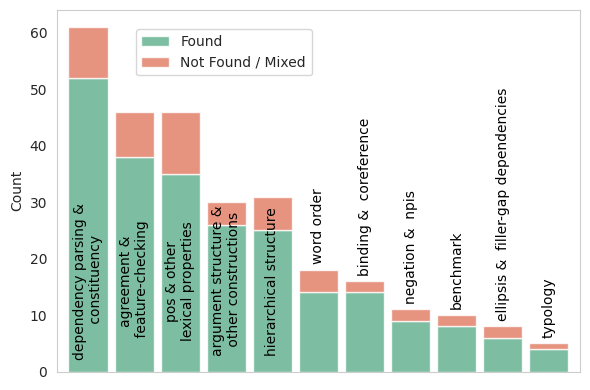

In [82]:
ax = percent.plot(kind='bar', stacked=True, figsize=(6, 4), color=['#5DAE8B', '#E07A5F'], width=0.85, alpha=0.8) # #4CAF50 #F44336

old_labels = percent.index.tolist()
new_labels = [
    label.replace('and', '&\n').lower().replace('pos', 'pos & other\nlexical properties')
    for label in old_labels
]

for i, (label_text, (index, row)) in enumerate(zip(new_labels, percent.iterrows())):
    total_bar_height = row.sum()

    if total_bar_height > 20:
        ax.text(
            i,
            16,
            label_text,
            ha='center',
            va='center',
            rotation=90,
            color='black',
            fontsize=10,
            #fontweight='bold'
        )
    else:
        ax.text(
            i,
            total_bar_height + 1,
            label_text.replace('\n', ' '),
            ha='center',
            va='bottom', # Changed to bottom for floating logic
            rotation=90,
            color='black',
            fontsize=10,
            #fontweight='bold'
        )

ax.set_xticklabels([])
ax.set_xlabel('')
ax.grid(False)

handles, labels = ax.get_legend_handles_labels()

plt.legend(
    handles,
    [labels[i].replace("/","/\n").lower() for i in range(len(labels))],
    title='Strength of\nEvidence',
    bbox_to_anchor=(0.82, 0.97),
    loc='upper center',
    frameon=True
)

plt.ylabel('Count')
#ax.set_xlabel('Syntactic Phenomena', fontsize=11)

#ax.set_title('Probing "Found" vs Not Found/Mixed by Syntactic Phenomena', fontweight='bold', pad=15)
ax.set_xticklabels([])
#ax.text(1.95, 1.05, "Probing-based", transform=ax1.transAxes, fontsize=19, fontweight='bold', ha='right', va='top') #transform=ax1.transAxes,

plt.legend(['Found', 'Not Found / Mixed'], loc="lower right", frameon=True, bbox_to_anchor=(0.5, 0.8)) #edgecolor='black'
plt.tight_layout()

try:
    plt.savefig("probing_individ_ling_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)


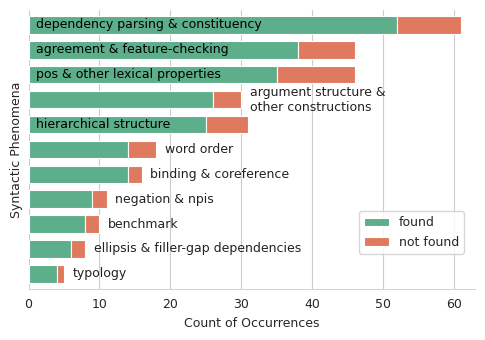

In [83]:
colors = ['#5DAE8B', '#E07A5F']
df_plot = percent.iloc[::-1]
n_bars = len(df_plot)
fig, ax = plt.subplots(figsize=(5, max(3.5, 0.2 * n_bars)))

y_pos = np.arange(n_bars)
df_plot.plot(
    kind='barh',
    stacked=True,
    color=colors[:len(df_plot.columns)],
    #edgecolor="white",
    linewidth=0.8,
    width=0.7,
    ax=ax
)

for y, (index_label, row) in enumerate(df_plot.iterrows()):
    val = row.sum()

    clean_label = (
        str(index_label)
        .lower()
        .replace(' and ', ' & ')
        .replace('argument structure & other construction', 'argument structure &\nother construction')
        .replace('pos', 'pos & other lexical properties')
    )

    if val >= 31:
        ax.text(
            1.0, y,
            clean_label,
            va='center',
            ha='left',
            fontsize=9,
            color='black',
            weight='medium'
        )
    else:
        ax.text(
            val + 1.2, y,
            clean_label,
            va='center',
            ha='left',
            fontsize=9,
            color='#222222',
            weight='regular'
        )

# 4. Clean Y-axis, Spines, and Grid
ax.set_yticks([])                          # Hide default y-ticks
ax.set_ylabel('')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.6)

# Set comfortable X-axis range and grid
max_val = df_plot.sum(axis=1).max()
ax.set_xlim(0, 63) #max_val * 1.3
ax.set_xlabel("Count of Occurrences", fontsize=9) #labelpad=8
ax.set_ylabel("Syntactic Phenomena", fontsize=9)

ax.tick_params(axis='x', labelsize=9)

#ax.grid(axis='x', linestyle=':', alpha=0.5, color='#cccccc')
#ax.set_axisbelow(True)

# 5. Clean Legend
handles, labels = ax.get_legend_handles_labels()
#clean_legend = [l.replace('_', ' ').replace('/', ' / ').lower() for l in labels]

ax.legend(
    handles,
    ['found', 'not found'],#/ mixed
    #title='Strength of Evidence',
    #frameon=False,
    bbox_to_anchor=(0.725,0.3),
    loc='upper left',
    fontsize=9,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig("probing_individ_ling_phenomena.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [84]:
percent = collapsed.div(collapsed.sum(axis=1), axis=0) * 100
percent = percent.round(1)  # optional, round to 1 decimal
percent

grouped,found,not_found_or_mixed
syntactic_phenomena,,
agreement and feature-checking,82.6,17.4
argument structure and other constructions,86.7,13.3
benchmark,80.0,20.0
binding and coreference,87.5,12.5
dependency parsing and constituency,85.2,14.8
ellipsis and filler-gap dependencies,75.0,25.0
hierarchical structure,80.6,19.4
negation and npis,81.8,18.2
pos,76.1,23.9


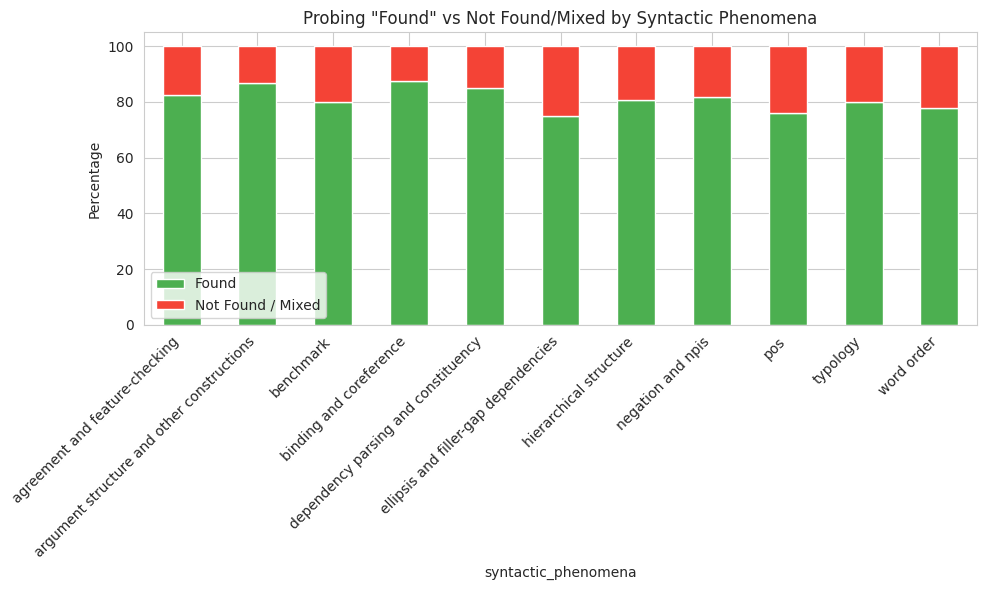

In [85]:
percent.plot(kind='bar', stacked=True, figsize=(10,6), color=['#4CAF50', '#F44336'])
plt.ylabel('Percentage')
plt.title('Probing "Found" vs Not Found/Mixed by Syntactic Phenomena')
plt.xticks(rotation=45, ha='right')
plt.legend(['Found', 'Not Found / Mixed'], loc="lower left")
plt.tight_layout()
plt.show()

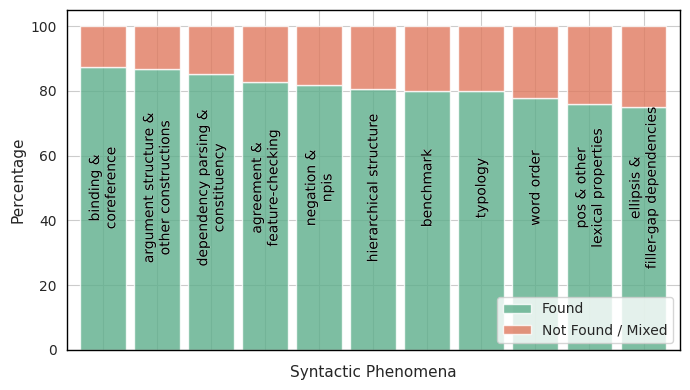

In [86]:
percent = percent.sort_values(by=percent.columns[0], ascending=False)
ax = percent.plot(kind='bar', stacked=True, figsize=(7, 4), color=['#5DAE8B', '#E07A5F'], width=0.85, alpha=0.8) # #4CAF50 #F44336

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if y == 0 and height > 25:
        raw_label = percent.index[int(x + width/2)]

        clean_label = raw_label.replace(" and ", " &\n")
        clean_label = clean_label.replace("pos", "pos & other\nlexical properties")

        txt = ax.text(
            x + width/2,
            50,  # Vertical anchor inside the first bar
            clean_label,
            ha='center',
            va='center',
            rotation=90,
            color='black',
            fontsize=10
        )

        txt.set_path_effects([
            path_effects.withStroke(linewidth=0.5, foreground='white', alpha=0.5)
        ])

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.set_ylabel('Percentage', fontsize=11)
ax.set_xlabel('Syntactic Phenomena', fontsize=11)

#ax.set_title('Probing "Found" vs Not Found/Mixed by Syntactic Phenomena', fontweight='bold', pad=15)
ax.set_xticklabels([])

plt.legend(['Found', 'Not Found / Mixed'], loc="lower right", frameon=True) #edgecolor='black'
plt.tight_layout()

try:
    plt.savefig("probing_individ_ling_phenomena2.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)


plt.show()

# 4. Mechanistic Interpretability
Syntactic evidence, crossed with model type, ling. phenomena, language English and Non-English

1. What kind of analysis approach: **Method**
2. **Model Type** x mechanistic_interpretability
3. **Syntactic phenomena** x mechanistic_interpretability
4. **Language** (Eng/Non-Eng comparioson) x mechanistic_interpretability


In [87]:
df = pd.read_csv("database_final.csv", sep=";")

palette = {
    "bidir": "#1f77b4",  # blue
    "both": "#FAF0DC",  # beige
    "causal": "#ff7f0e",  # orange
}

# Configuration
cols = [
    "Mechanistic_Syntactic evidence/ awareness"
]

## 1. Method

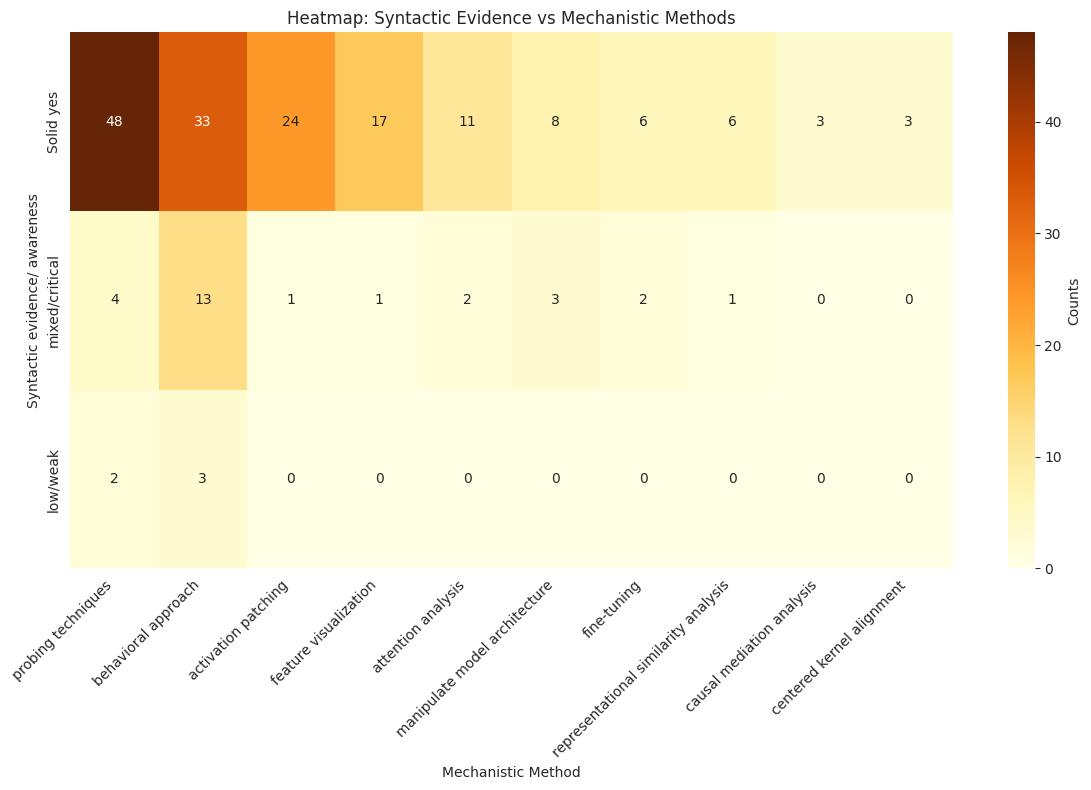

In [88]:
col_syn = "Mechanistic_Syntactic evidence/ awareness"
col_mech = "Mechanistic_method"

df_heat = df[[col_syn, col_mech]].copy()

df_heat[col_mech] = df_heat[col_mech].apply(
    lambda x: [re.sub(r"\s*\(.*?\)", "", i).lower().strip() for i in str(x).split(',')] if pd.notna(x) else []
)
df_heat = df_heat.explode(col_mech)
df_heat = df_heat.dropna(subset=[col_syn, col_mech])
df_heat = df_heat[(df_heat[col_syn] != "") & (df_heat[col_mech] != "")]

pivot = pd.crosstab(df_heat[col_syn], df_heat[col_mech])

top_syn = df_heat[col_syn].value_counts().nlargest(15).index
top_mech = df_heat[col_mech].value_counts().nlargest(10).index
pivot_filtered = pivot.loc[top_syn, top_mech]

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_filtered,
    annot=True,          # Show the numbers in the cells
    fmt="d",             # Format as integers
    cmap="YlOrBr",
    cbar_kws={'label': 'Counts'}
)

plt.title("Heatmap: Syntactic Evidence vs Mechanistic Methods")
plt.xlabel("Mechanistic Method")
plt.ylabel("Syntactic evidence/ awareness")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Model Type

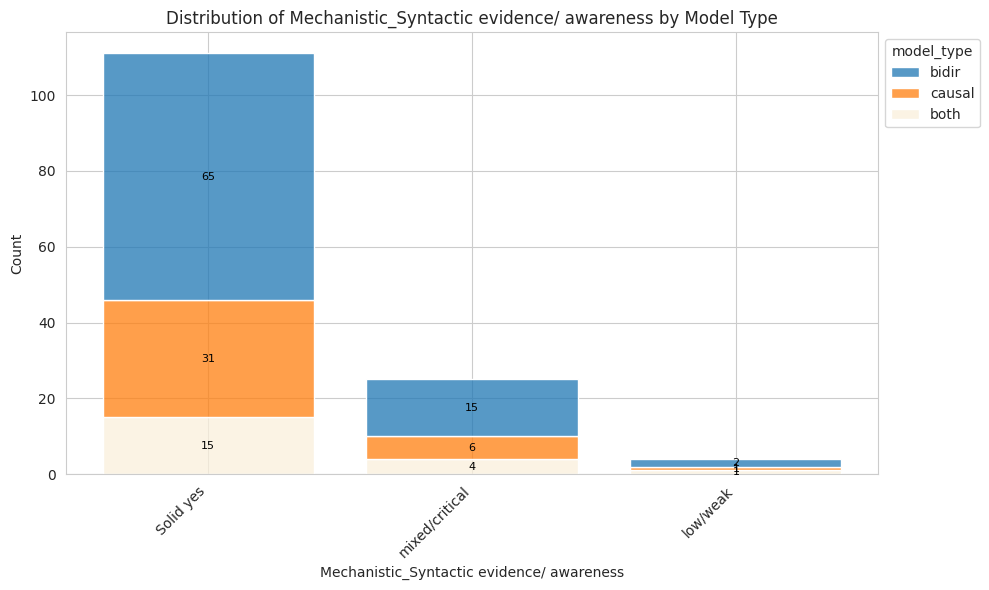

In [89]:
# Configuration
cols = [
    "Mechanistic_Syntactic evidence/ awareness"
]
hue_col = 'model_type'
desired_order = ['bidir', 'causal', 'both']
colors = {'bidir': 'skyblue', 'causal': 'orange', 'both': 'purple'}

for col in cols:
    # Prepare data
    df_temp = df[[col, hue_col]].copy()
    df_temp[col] = df_temp[col].apply(lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else [])
    df_temp = df_temp.explode(col).dropna(subset=[col])
    df_temp = df_temp[df_temp[col] != "nan"] # Clean up string 'nan' if present

    plt.figure(figsize=(10, 6))

    # Plot
    ax = sns.histplot(
        data=df_temp,
        x=col,
        hue=hue_col,
        multiple="stack",
        shrink=0.8,
        palette=palette,
        hue_order=desired_order
    )

    # Label non-zero segments
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

    plt.title(f"Distribution of {col} by Model Type")
    plt.xticks(rotation=45, ha='right')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

## 3. Linguistic Phenomena

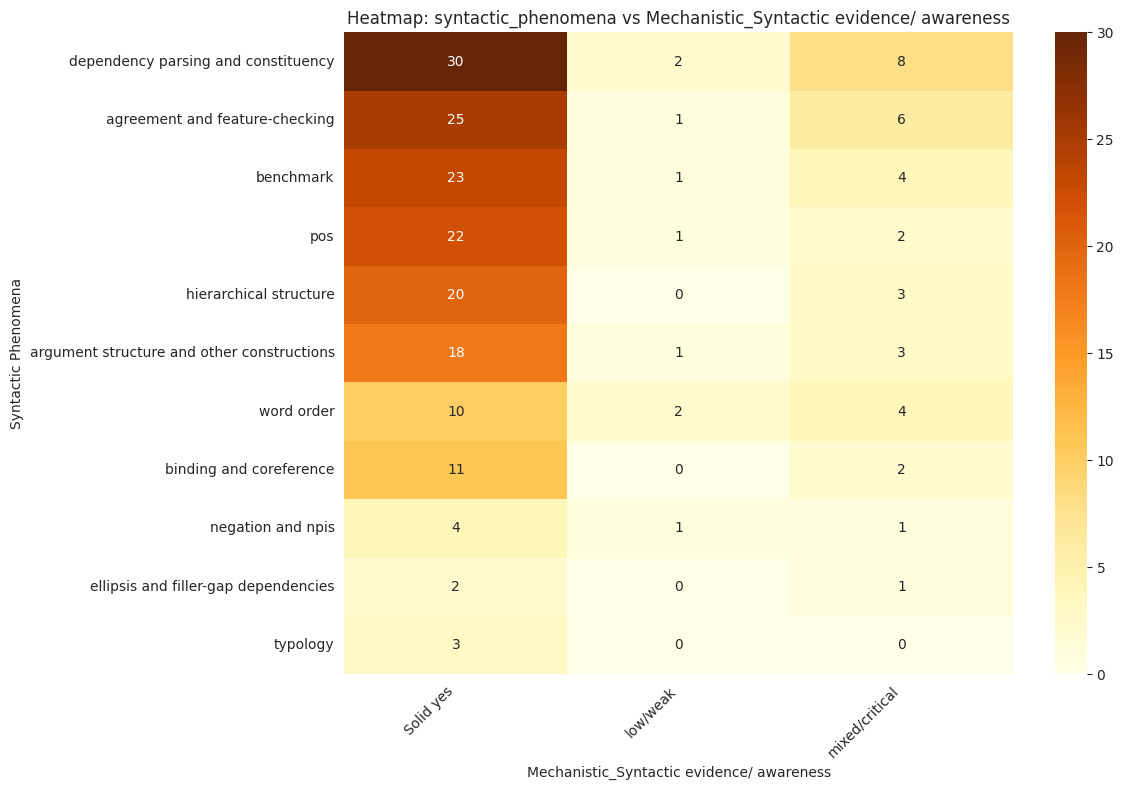

In [90]:
syn_col = "syntactic_phenomena"

for mech_col in cols:
    df_heat = df[[syn_col, mech_col]].copy()

    df_heat[syn_col] = df_heat[syn_col].apply(clean_syntactic_phenomena)
    df_heat = df_heat.explode(syn_col)

    df_heat[mech_col] = df_heat[mech_col].apply(
        lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
    )
    df_heat = df_heat.explode(mech_col)

    df_heat = df_heat.dropna(subset=[syn_col, mech_col])
    df_heat = df_heat[(df_heat[syn_col] != "") & (df_heat[mech_col] != "nan")]

    pivot = pd.crosstab(df_heat[syn_col], df_heat[mech_col])

    # Optional: limit to top 15 phenomena for readability
    top_syn = df_heat[syn_col].value_counts().nlargest(15).index
    pivot = pivot.loc[top_syn]

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrBr")

    plt.title(f"Heatmap: {syn_col} vs {mech_col}")
    plt.xlabel(mech_col)
    plt.ylabel("Syntactic Phenomena")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

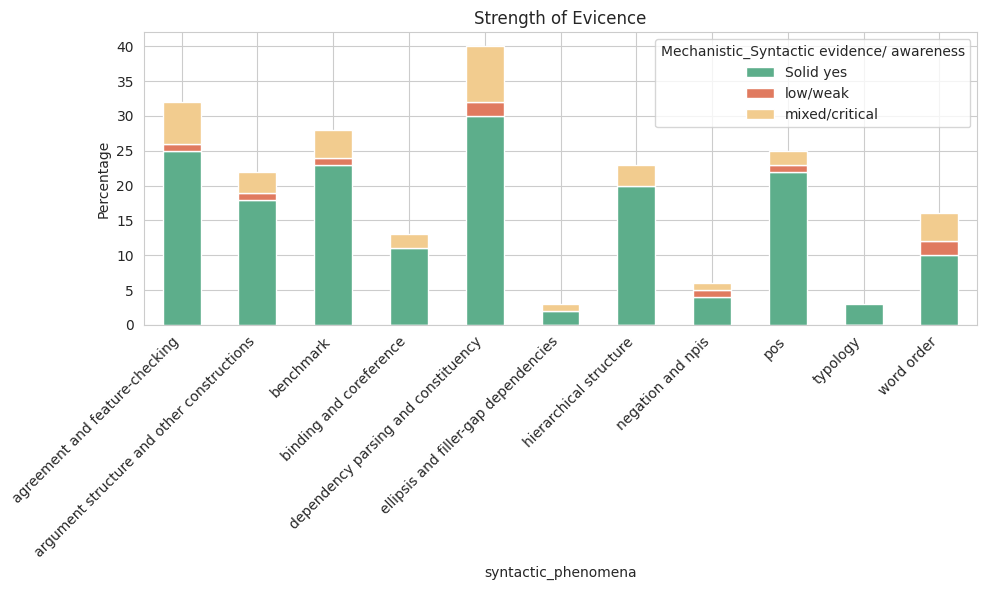

In [91]:
mech_col= "Mechanistic_Syntactic evidence/ awareness"

pivot = pd.crosstab(df_heat[syn_col], df_heat[mech_col])

percent = pivot
#percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
percent = percent.round(1)  # optional, round to 1 decimal

percent.plot(kind='bar', stacked=True, figsize=(10,6), color= ['#5DAE8B', '#E07A5F', '#F2CC8F']) #['#4CAF50', '#F44336', '#FFFF00'])
plt.ylabel('Percentage')
plt.title('Strength of Evicence')
plt.xticks(rotation=45, ha='right')
#plt.legend(['Found', 'Not Found / Mixed'])
plt.tight_layout()
plt.show()

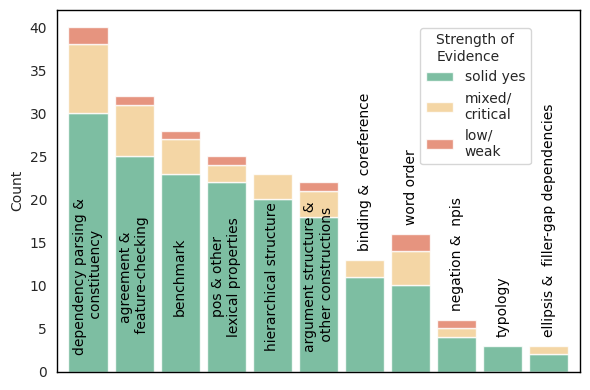

In [92]:
desired_stack_order = [percent.columns[0], percent.columns[2], percent.columns[1]]
# Reorder the dataframe columns
percent = percent[desired_stack_order]

percent_sorted = percent.sort_values(by=percent.columns[0], ascending=False)

ax = percent_sorted.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 4), alpha = 0.8,
    color=['#5DAE8B', '#F2CC8F', '#E07A5F'],
    width=0.85
)

old_labels = percent_sorted.index.tolist()
new_labels = [
    label.replace('and', '&\n').lower().replace('pos', 'pos & other\nlexical properties')
    for label in old_labels
]

for i, (label_text, (index, row)) in enumerate(zip(new_labels, percent_sorted.iterrows())):
    total_bar_height = row.sum()

    if total_bar_height > 17:
        ax.text(
            i,
            11,
            label_text,
            ha='center',
            va='center',
            rotation=90,
            color='black',
            fontsize=10,
            #fontweight='bold'
        )
    else:
        ax.text(
            i,
            total_bar_height + 1,
            label_text.replace('\n', ' '),
            ha='center',
            va='bottom', # Changed to bottom for floating logic
            rotation=90,
            color='black',
            fontsize=10,
            #fontweight='bold'
        )

ax.set_xticklabels([])
ax.set_xlabel('')
ax.grid(False)

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    [labels[i].replace("/","/\n").lower() for i in range(len(labels))],
    title='Strength of\nEvidence',
    bbox_to_anchor=(0.8, 0.97),
    loc='upper center',
    frameon=True
)

plt.ylabel('Count')
#ax.text(1.15, 1.1, "Mechanistic\n interpretability", transform=ax1.transAxes, fontsize=17, fontweight='bold', ha='right', va='top') #transform=ax1.transAxes,

# Optional: Add black frame back if desired
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("Counts_mech_syntactic.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()

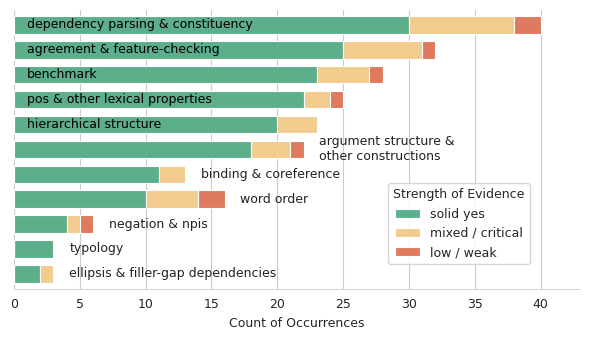

In [93]:
#desired_stack_order = [percent.columns[0], percent.columns[2], percent.columns[1]]
#percent_reordered = percent[desired_stack_order]

df_plot = percent_sorted.sort_values(by=percent_sorted.columns[0], ascending=True)
n_bars = len(df_plot)

colors = ['#5DAE8B', '#F2CC8F', '#E07A5F']

fig, ax = plt.subplots(figsize=(6, max(3.5, 0.2 * n_bars)))

y_pos = np.arange(n_bars)
df_plot.plot(
    kind='barh',
    stacked=True,
    color=colors,
    edgecolor=None,
    linewidth=0.8,
    width=0.7,
    ax=ax
)

# 3. Clean Text Placement (No numbers)
for y, (index_label, row) in enumerate(df_plot.iterrows()):
    val = row.sum()

    # Format category label cleanly
    clean_label = (
        str(index_label)
        .lower()
        .replace(' and ', ' & ')
        .replace('pos', 'pos & other lexical properties')
        .replace('argument structure & other construction', 'argument structure &\nother construction')

    )

    # Wide bars: Place text INSIDE the green bar segment
    if val >= 23:
        ax.text(
            1.0, y,
            clean_label,
            va='center',
            ha='left',
            fontsize=9,
            color='black',
            weight='medium'
        )
    else:
        ax.text(
            val + 1.2, y,
            clean_label,
            va='center',
            ha='left',
            fontsize=9,
            color='#222222',
            weight='regular'
        )

# 4. Spines, Y-Ticks, and Grid formatting
ax.set_yticks([])
ax.set_ylabel('')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.6)

# Set comfortable X-axis headroom
max_val = df_plot.sum(axis=1).max()
ax.set_xlim(0, 43)
ax.set_xlabel("Count of Occurrences", fontsize=9)
#ax.set_xlabel("Syntactic Phenomena", fontsize=9)
ax.tick_params(axis='x', labelsize=9)

#ax.grid(axis='x', linestyle=':', alpha=0.5, color='#cccccc')
#ax.set_axisbelow(True)

# 5. Clean Side Legend
handles, labels = ax.get_legend_handles_labels()
clean_legend = [l.replace('_', ' ').replace('/', ' / ').lower() for l in labels]

ax.legend(
    handles,
    clean_legend,
    title='Strength of Evidence',
    #frameon=False,
    bbox_to_anchor=(0.65, 0.4),
    loc='upper left',
    fontsize=9,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig("Counts_mech_syntactic.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

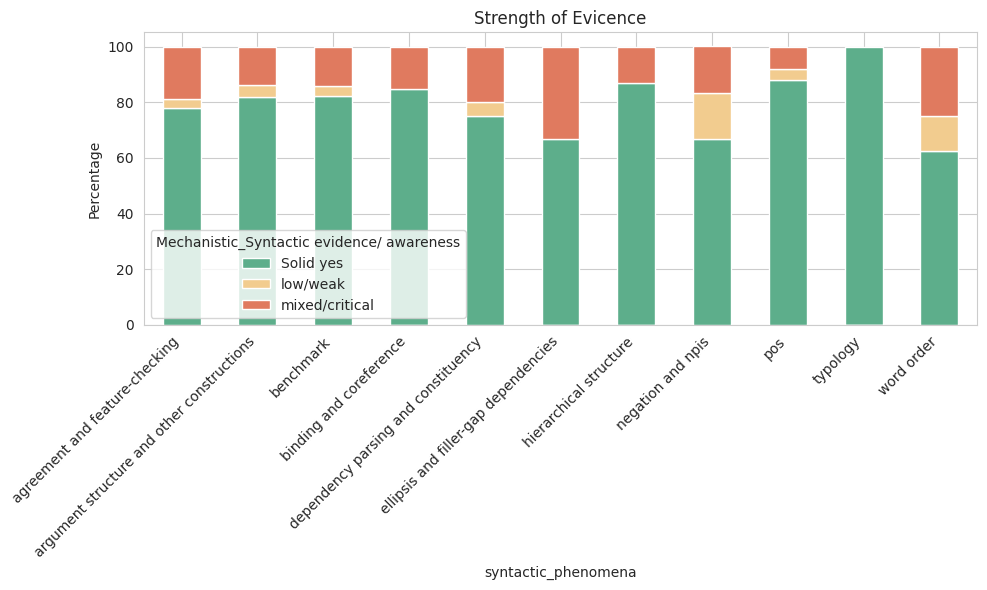

In [94]:
mech_col= "Mechanistic_Syntactic evidence/ awareness"

pivot = pd.crosstab(df_heat[syn_col], df_heat[mech_col])

percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
percent = percent.round(1)  # optional, round to 1 decimal

percent.plot(kind='bar', stacked=True, figsize=(10,6), color= ['#5DAE8B', '#F2CC8F', '#E07A5F']) #['#4CAF50', '#F44336', '#FFFF00'])
plt.ylabel('Percentage')
plt.title('Strength of Evicence')
plt.xticks(rotation=45, ha='right')
#plt.legend(['Found', 'Not Found / Mixed'])
plt.tight_layout()
plt.show()

In [95]:
percent

Mechanistic_Syntactic evidence/ awareness,Solid yes,low/weak,mixed/critical
syntactic_phenomena,,,
agreement and feature-checking,78.1,3.1,18.8
argument structure and other constructions,81.8,4.5,13.6
benchmark,82.1,3.6,14.3
binding and coreference,84.6,0.0,15.4
dependency parsing and constituency,75.0,5.0,20.0
ellipsis and filler-gap dependencies,66.7,0.0,33.3
hierarchical structure,87.0,0.0,13.0
negation and npis,66.7,16.7,16.7
pos,88.0,4.0,8.0


In [96]:
pivot["Solid yes"].sum()
pivot.sum() #11100/140

,0
Mechanistic_Syntactic evidence/ awareness,
Solid yes,168
low/weak,9
mixed/critical,34


##4. Language (Eng/Non-Eng comparioson) x mechanistic_interpretability

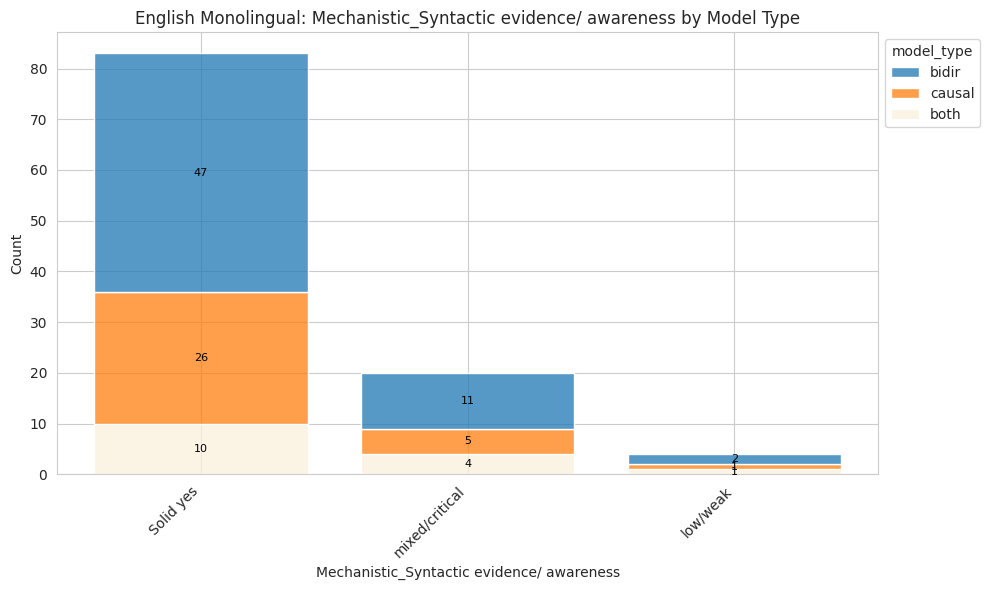

In [97]:
# Filtered for  languages_tested_monolingual_eng ONLY
cols = [
    "Mechanistic_Syntactic evidence/ awareness"
]
lang_col = "languages_tested_monolingual_eng"
hue_col = 'model_type'
desired_order = ['bidir', 'causal', 'both']
colors = {'bidir': 'skyblue', 'causal': 'orange', 'both': 'purple'}

df_eng = df[df[lang_col] == True].copy()

for col in cols:
    # Prep data
    df_temp = df_eng[[col, hue_col]].copy()
    df_temp[col] = df_temp[col].apply(lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else [])
    df_temp = df_temp.explode(col).dropna(subset=[col])
    df_temp = df_temp[~df_temp[col].isin(["nan", "None", ""])]

    plt.figure(figsize=(10, 6))

    ax = sns.histplot(
        data=df_temp,
        x=col,
        hue=hue_col,
        multiple="stack",
        shrink=0.8,
        palette=palette,
        hue_order=desired_order
    )

    # Label non-zero segments
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

    plt.title(f"English Monolingual: {col} by Model Type")
    plt.xticks(rotation=45, ha='right')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

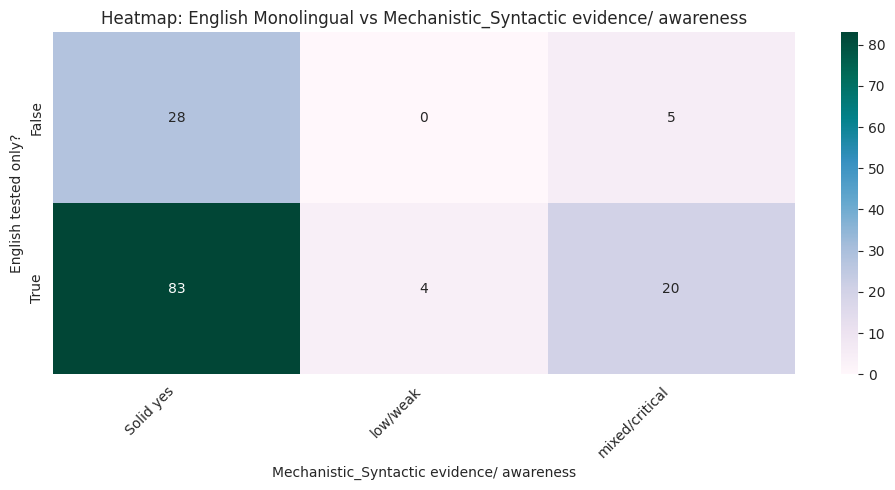

In [98]:
for mech_col in cols:
    df_heat = df[[lang_col, mech_col]].copy()

    df_heat[mech_col] = df_heat[mech_col].apply(
        lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
    )
    df_heat = df_heat.explode(mech_col)

    df_heat = df_heat.dropna(subset=[lang_col, mech_col])
    df_heat = df_heat[~df_heat[mech_col].isin(["nan", "None", ""])]

    # 4. Create Crosstab
    # This shows: Rows = English (True/False), Columns = Mechanistic Property
    pivot = pd.crosstab(df_heat[lang_col], df_heat[mech_col])

    # 5. Plot Heatmap
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="PuBuGn")

    plt.title(f"Heatmap: English Monolingual vs {mech_col}")
    plt.xlabel(mech_col)
    plt.ylabel("English tested only?")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

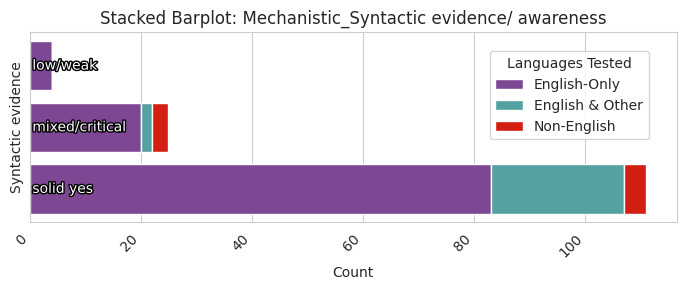

In [100]:
# ling phenomena x lang counts and  method?

CATEGORY_ORDER = ['English-Only', 'English & Other', 'Non-English']

for mech_col in cols:
    df_plot = df[[syn_col, mech_col,
                  'languages_tested_monolingual_eng',
                  'languages_tested_eng_included']].copy()

    # Normalize text column
    df_plot[mech_col] = df_plot[mech_col].astype(str).str.lower()

    # Split + explode
    df_plot[mech_col] = df_plot[mech_col].apply(
        lambda x: [i.strip() for i in x.split(',')] if pd.notna(x) else []
    )
    df_plot = df_plot.explode(mech_col)

    # Clean
    df_plot = df_plot.dropna(subset=[mech_col])
    df_plot = df_plot[~df_plot[mech_col].isin(["nan", "none", ""])]

    # Get counts per category (x-axis)
    counts = df_plot[mech_col].value_counts()
    #top_n = 10
    #counts = counts.head(top_n)
    #df_plot = df_plot[df_plot[mech_col].isin(counts.index)]

    bar_data_dict, stack_df = calculate_bar_data_stacked(df_plot, counts, mech_col)
    plt.figure(figsize=(7, 3))

    bottom = None
    left = None
    for category in CATEGORY_ORDER:
        values = stack_df[category]
        if left is None:
            plt.barh(stack_df.index, values, label=category, color=COLOR_MAP[category], alpha=1)
            left = values.copy()
        else:
            plt.barh(stack_df.index, values, left=left, label=category,color=COLOR_MAP[category])
            left += values
    # --- put labels INSIDE bars ---
    for i, label in enumerate(stack_df.index):
        txt = plt.text(
        0.5, i,
        label,
        va='center',
        ha='left',
        fontsize=10,
        color='white'
        )

        txt.set_path_effects([
        path_effects.withStroke(linewidth=2, foreground='black')
        ])

    plt.yticks([])  # hide default labels

    plt.title(f"Stacked Barplot: {mech_col}")
    plt.xlabel("Count")
    plt.ylabel(mech_col.replace("Mechanistic_", " "))
    plt.ylabel("Syntactic evidence")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Languages Tested",bbox_to_anchor=(0.7, 0.4))
    plt.tight_layout()
    plt.show()

In [101]:
len(df_plot[mech_col])

140

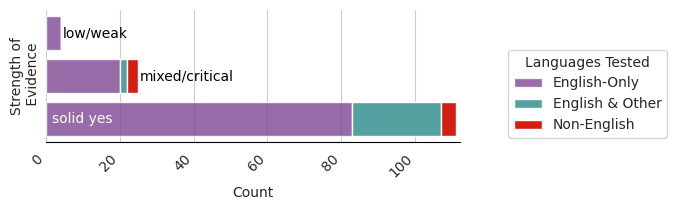

In [102]:
# ling phenomena x lang counts and  method?

CATEGORY_ORDER = ['English-Only', 'English & Other', 'Non-English']

for mech_col in cols:
    df_plot = df[[syn_col, mech_col,
                  'languages_tested_monolingual_eng',
                  'languages_tested_eng_included']].copy()

    df_plot[mech_col] = df_plot[mech_col].astype(str).str.lower()
    df_plot[mech_col] = df_plot[mech_col].apply(
        lambda x: [i.strip() for i in x.split(',')] if pd.notna(x) else []
    )
    df_plot = df_plot.explode(mech_col)

    df_plot = df_plot.dropna(subset=[mech_col])
    df_plot = df_plot[~df_plot[mech_col].isin(["nan", "none", ""])]

    counts = df_plot[mech_col].value_counts()

    bar_data_dict, stack_df = calculate_bar_data_stacked(df_plot, counts, mech_col)
    plt.figure(figsize=(7, 2.2))

    bottom = None
    left = None
    for category in CATEGORY_ORDER:
        values = stack_df[category]
        if left is None:
            plt.barh(stack_df.index, values, label=category, color=COLOR_MAP[category], alpha=0.8)
            left = values.copy()
        else:
            plt.barh(stack_df.index, values, left=left, label=category,color=COLOR_MAP[category])
            left += values

    total_widths = stack_df.sum(axis=1)

    for i, (label, total_len) in enumerate(zip(stack_df.index, total_widths)):

        if total_len < 30:
            x_pos = total_len + 0.5
            text_color = 'black'
            h_align = 'left'
            effect = []
        else:
            x_pos = 1.7
            text_color = 'white'
            h_align = 'left'
            effect = [path_effects.withStroke(linewidth=1, foreground='white')]

        txt = plt.text(
            x_pos, i,
            label,
            va='center',
            ha=h_align,
            fontsize=10,
            color=text_color
        )


    plt.yticks([])
    plt.xlim(0, max(total_widths) * 1.01)

    plt.xlabel("Count")
    plt.ylabel("Mechanistic\nAwareness")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Languages Tested", bbox_to_anchor=(1, 1.1), loc='upper left', ncol=1)

    plt.yticks([])
    plt.xlim(0, max(total_widths) * 1.01)

    plt.xlabel("Count")
    plt.ylabel("Strength of\n Evidence")

    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Languages Tested", bbox_to_anchor=(1.1, 0.75), loc='upper left', ncol=1)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')


plt.tight_layout()

try:
    plt.savefig("mechanistic_evidence_by_language.pdf", format='pdf', dpi=300, bbox_inches='tight')
except Exception as e:
    print("\n ERROR saving PDF:", e)
plt.show()

In [103]:
pivot.sum()

,0
Mechanistic_Syntactic evidence/ awareness,
Solid yes,111
low/weak,4
mixed/critical,25


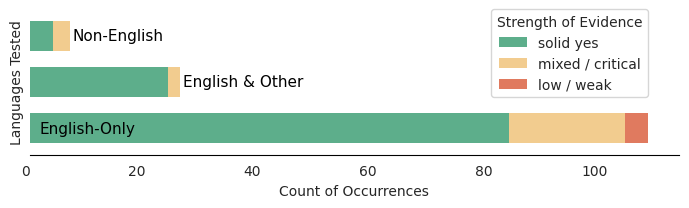

In [104]:
CATEGORY_ORDER = ['English-Only', 'English & Other', 'Non-English']
TRAFFIC_LIGHT_COLORS = ['#5DAE8B','#F2CC8F', '#E07A5F']

for mech_col in cols:
    df_plot = df[[syn_col, mech_col,
                  'languages_tested_monolingual_eng',
                  'languages_tested_eng_included']].copy()

    df_plot[mech_col] = df_plot[mech_col].astype(str).str.lower()

    df_plot[mech_col] = df_plot[mech_col].apply(
        lambda x: [i.strip() for i in x.split(',')] if pd.notna(x) else []
    )
    df_plot = df_plot.explode(mech_col)

    df_plot = df_plot.dropna(subset=[mech_col])
    df_plot = df_plot[~df_plot[mech_col].isin(["nan", "none", ""])]

    conditions = [
        (df_plot['languages_tested_monolingual_eng'] == True) | (df_plot['languages_tested_monolingual_eng'] == 'True'),
        (df_plot['languages_tested_eng_included'] == True) | (df_plot['languages_tested_eng_included'] == 'True')
    ]
    choices = ['English-Only', 'English & Other']
    df_plot['lang_category'] = np.select(conditions, choices, default='Non-English')

    cross_tab = pd.crosstab(df_plot['lang_category'], df_plot[mech_col])
    cross_tab = cross_tab.reindex(CATEGORY_ORDER).fillna(0)

    column_totals = cross_tab.sum(axis=0)
    sorted_columns = column_totals.sort_values(ascending=False).index
    cross_tab = cross_tab[sorted_columns]

    # --- PLOTTING ---
    plt.figure(figsize=(7, 2.2))
    ax = cross_tab.plot(
        kind='barh',
        stacked=True,
        edgecolor='none',
        color=TRAFFIC_LIGHT_COLORS,
        ax=plt.gca(),
        width=0.65
    )

    total_widths = cross_tab.sum(axis=1)

    for i, (label, total_len) in enumerate(zip(cross_tab.index, total_widths)):
        if total_len < 30:
            x_pos = total_len + 0.5
            text_color = 'black'
            h_align = 'left'
            effect = []
        else:
            x_pos = 1.7
            text_color = 'black'
            h_align = 'left'

        txt = plt.text(
            x_pos, i,
            label,
            va='center',
            ha=h_align,
            fontsize=11,
            color=text_color
        )
        if effect:
            txt.set_path_effects(effect)

    ax.grid(False)
    plt.yticks([])
    plt.xlim(0, max(total_widths) * 1.05)

    plt.xlabel("Count of Occurrences")
    plt.ylabel("Languages Tested")
    plt.xticks(ha='right') #rotation=45

    evidence_labels = [str(col).lower().replace("/", " / ") for col in cross_tab.columns]
    plt.legend(evidence_labels, title="Strength of Evidence", bbox_to_anchor=(0.7, 1.05), loc='upper left', ncol=1)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')

    plt.tight_layout()

    try:
        plt.savefig(f"evidence_by_language_mech.pdf", format='pdf', dpi=300, bbox_inches='tight')
    except Exception as e:
        print("\n ERROR saving PDF:", e)
    plt.show()